## Import

In [2]:
import warnings
import numpy as np
from category_encoders import MEstimateEncoder
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import make_column_transformer
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.tree import DecisionTreeRegressor
from datetime import datetime
import json
from utilis_function.utilis_funcs import *
warnings.filterwarnings("ignore")

## Import Data 

In [3]:


csv_candidates = [
    Path("student_dataset/student_failure/train.csv"),
    Path("../student_dataset/student_failure/train.csv"),
]

for csv_path in csv_candidates:
    if csv_path.exists():
        data = pd.read_csv(csv_path)
        break


# Afficher les premières lignes du dataset
X = data.drop(["score_examen", "id"], axis=1)
y = data.score_examen
model_data = data.copy()
target_col = "score_examen"
id_col = "id"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=0
)

In [4]:
X.head()


,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,heures_fête,taille_etudiant
0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,5,1.91
1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,4,1.89
2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,4,1.72
3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,4,1.51
4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,2,1.94


## Data Exploration and Analysis

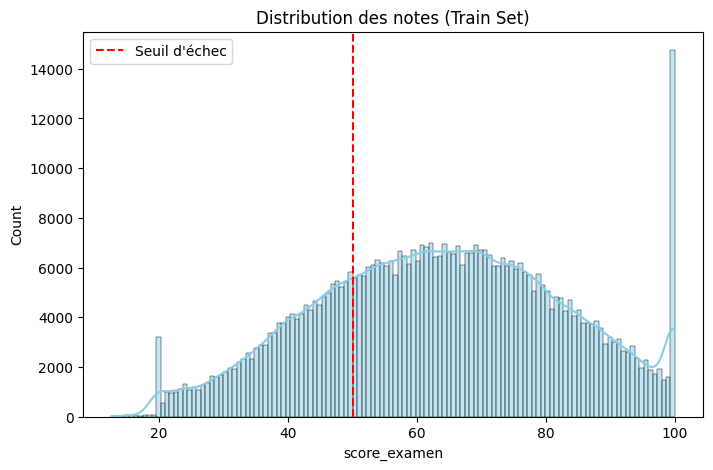

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(y_train, kde=True, color='skyblue')
plt.axvline(50, color='red', linestyle='--', label="Seuil d'échec")
plt.title("Distribution des notes (Train Set)")
plt.legend()
plt.savefig("../Graph/score_distribution.png")
plt.show()


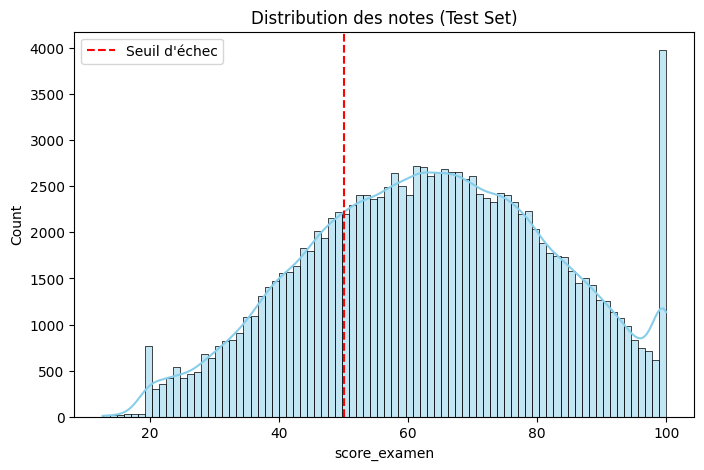

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(y_test, kde=True, color='skyblue')
plt.axvline(50, color='red', linestyle='--', label="Seuil d'échec")
plt.title("Distribution des notes (Test Set)")
plt.legend()
plt.savefig("../Graph/score_distribution_test.png")
plt.show()

### Correlations entre les entrée du tableau et du score final

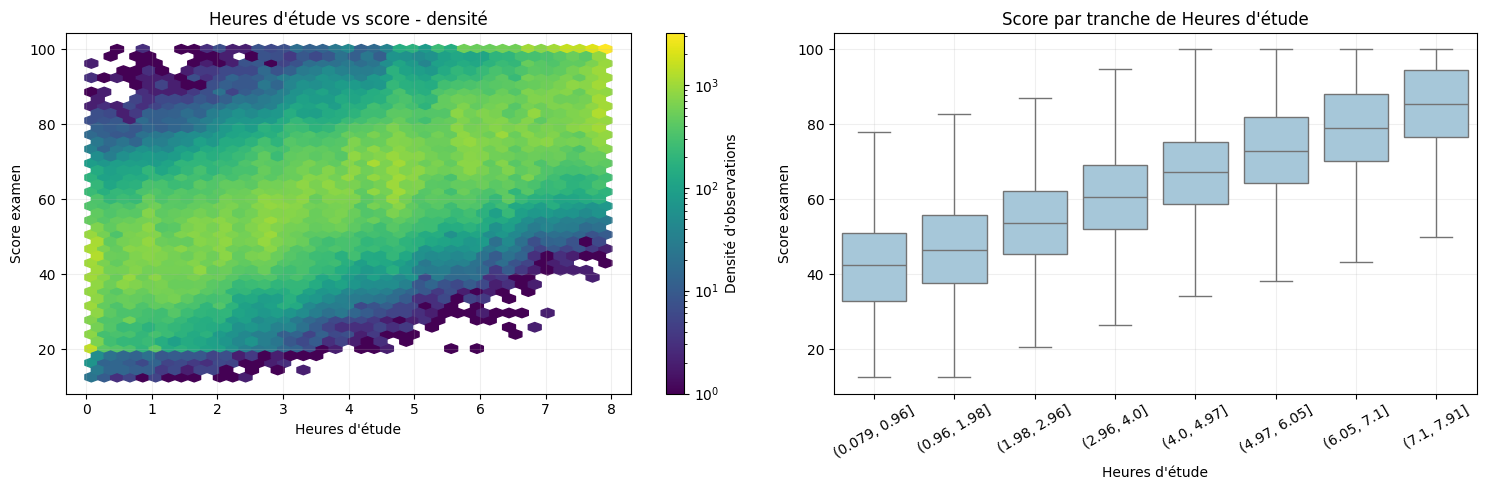

In [7]:
# Graphe entre les features et le score final
plot_numeric_score_density(
    X_train["heures_etude"],
    y_train,
    "Heures d'étude",
    "heures_etude_vs_score_density.png",
)


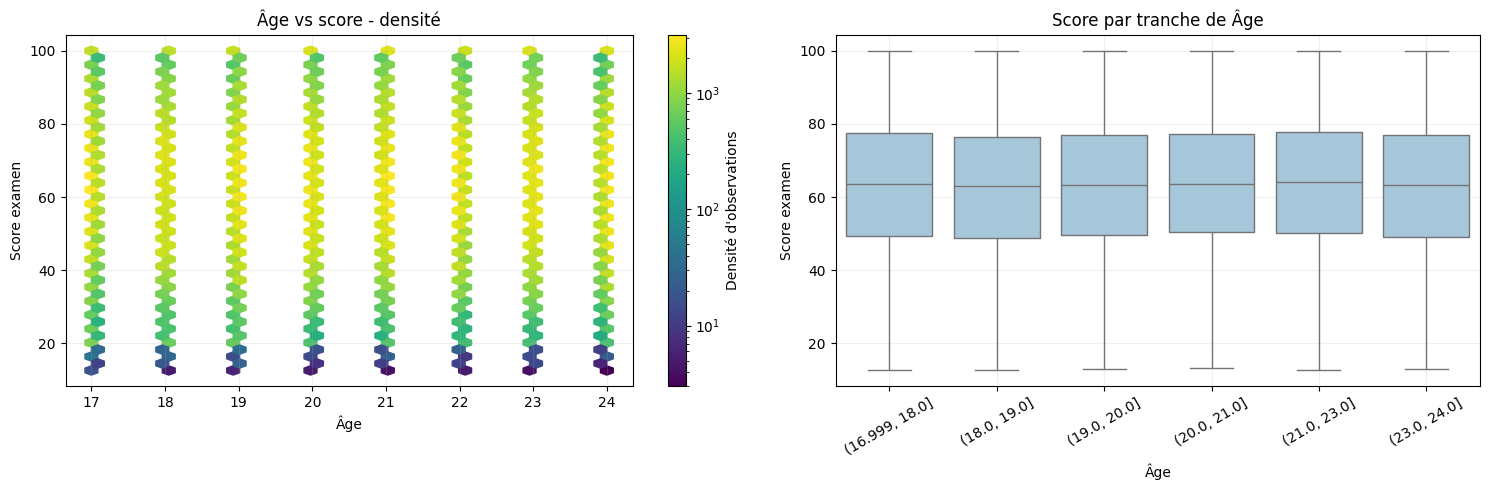

In [8]:
# graphes de l'age vs score
plot_numeric_score_density(
    X_train["age"],
    y_train,
    "Âge",
    "age_vs_score_density.png",
)


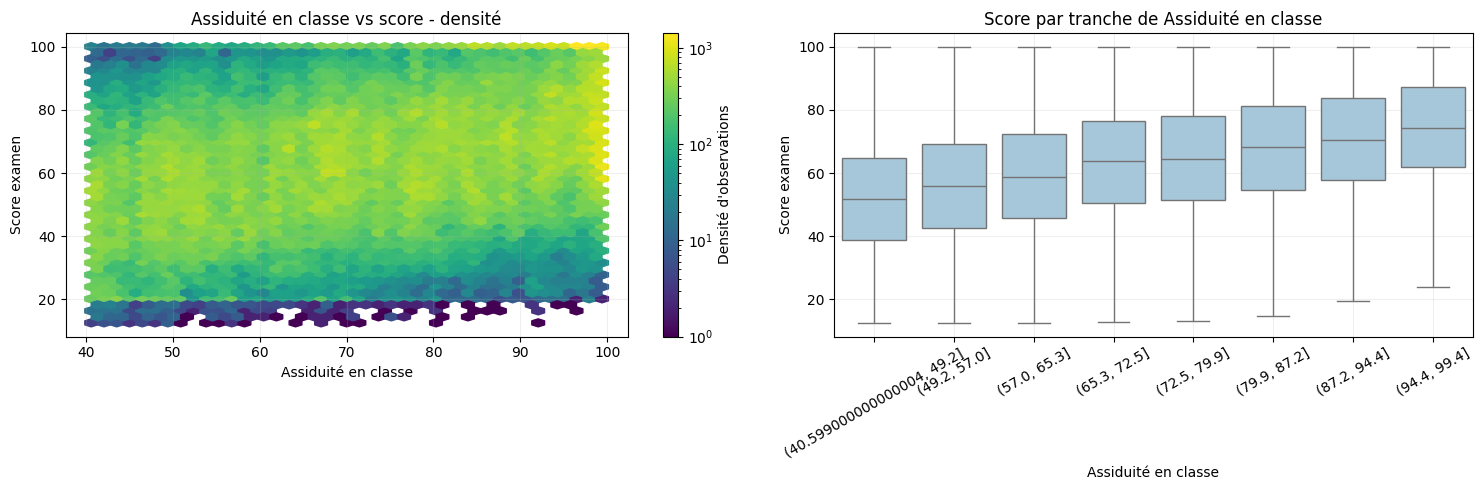

In [9]:
# graphes de l'assiduité vs score
plot_numeric_score_density(
    X_train["assiduité_classe"],
    y_train,
    "Assiduité en classe",
    "assiduite_vs_score_density.png",
)


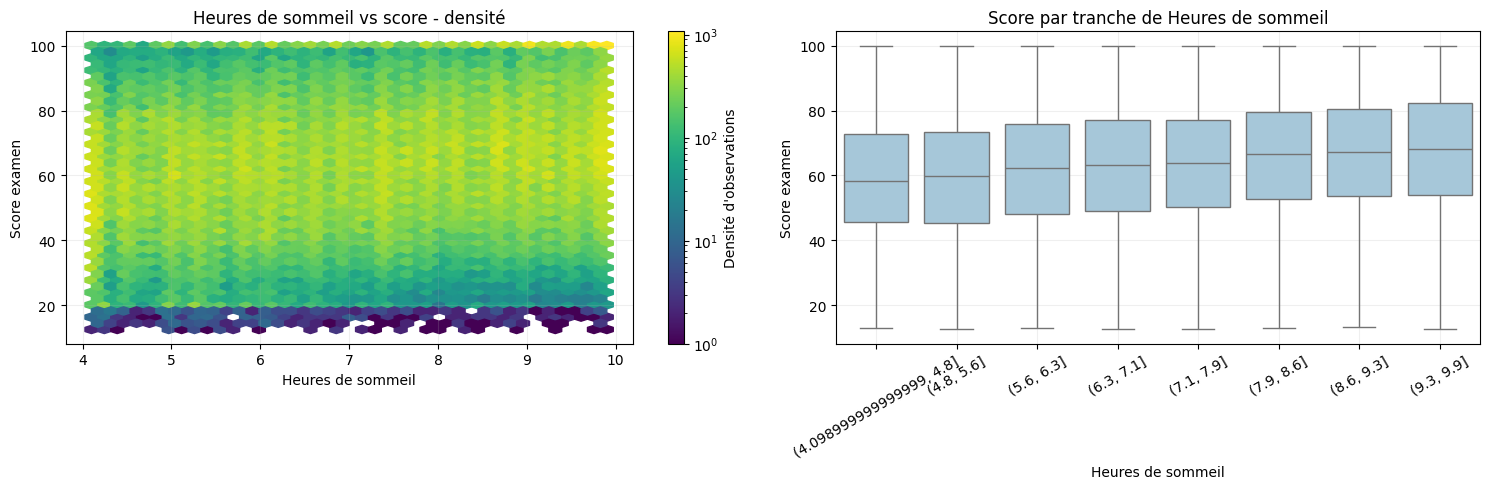

In [10]:
# graphe de heures de sommeil vs score
plot_numeric_score_density(
    X_train["heures_sommeil"],
    y_train,
    "Heures de sommeil",
    "heures_sommeil_vs_score_density.png",
)


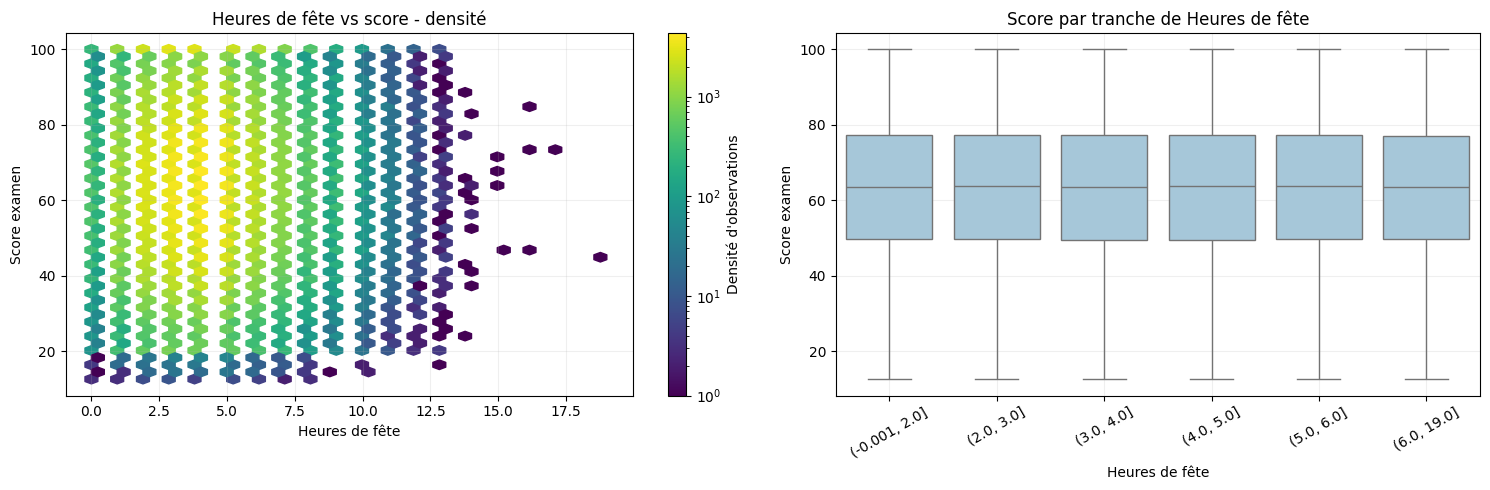

In [11]:
# graphes heures de fete vs score
plot_numeric_score_density(
    X_train["heures_fête"],
    y_train,
    "Heures de fête",
    "heures_fete_vs_score_density.png",
)


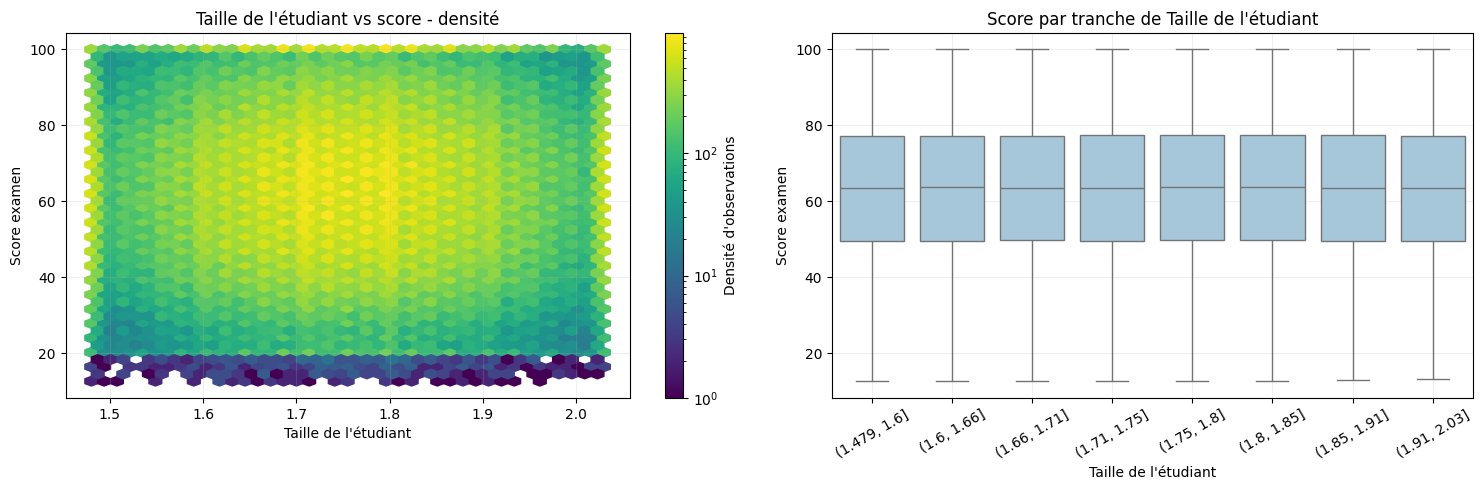

In [12]:
#graphes taille vs score
plot_numeric_score_density(
    X_train["taille_etudiant"],
    y_train,
    "Taille de l'étudiant",
    "taille_vs_score_density.png",
)


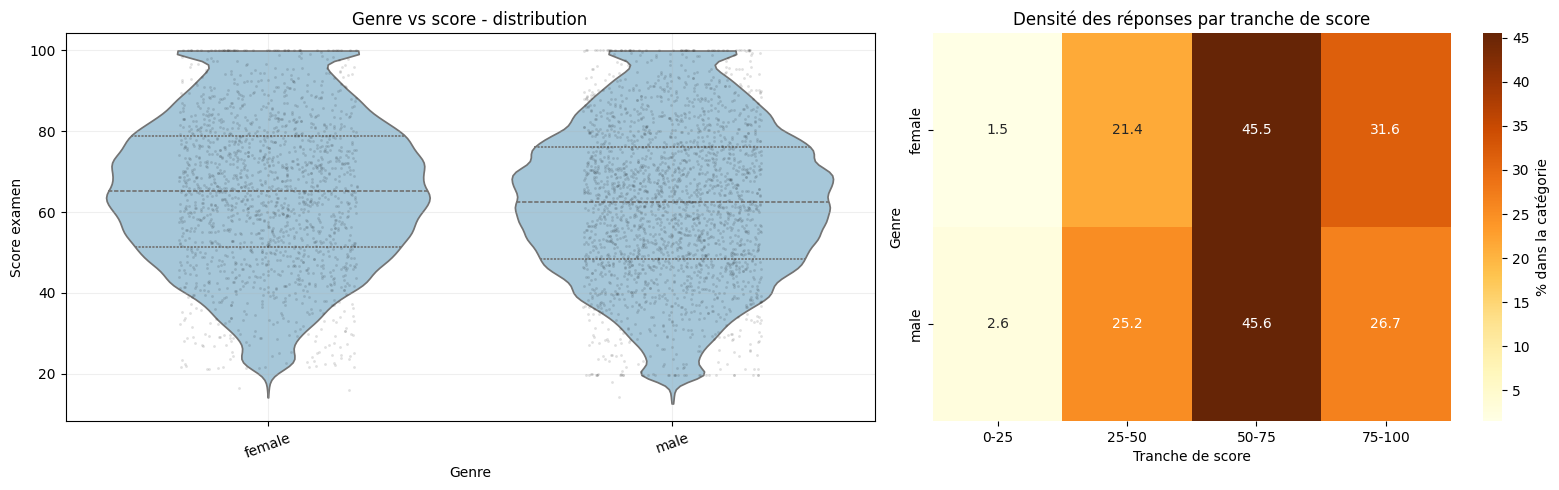

In [13]:
# histogramme genre vs score
plot_categorical_score_density(
    X_train["genre"],
    y_train,
    "Genre",
    "genre_vs_score_density.png",
)


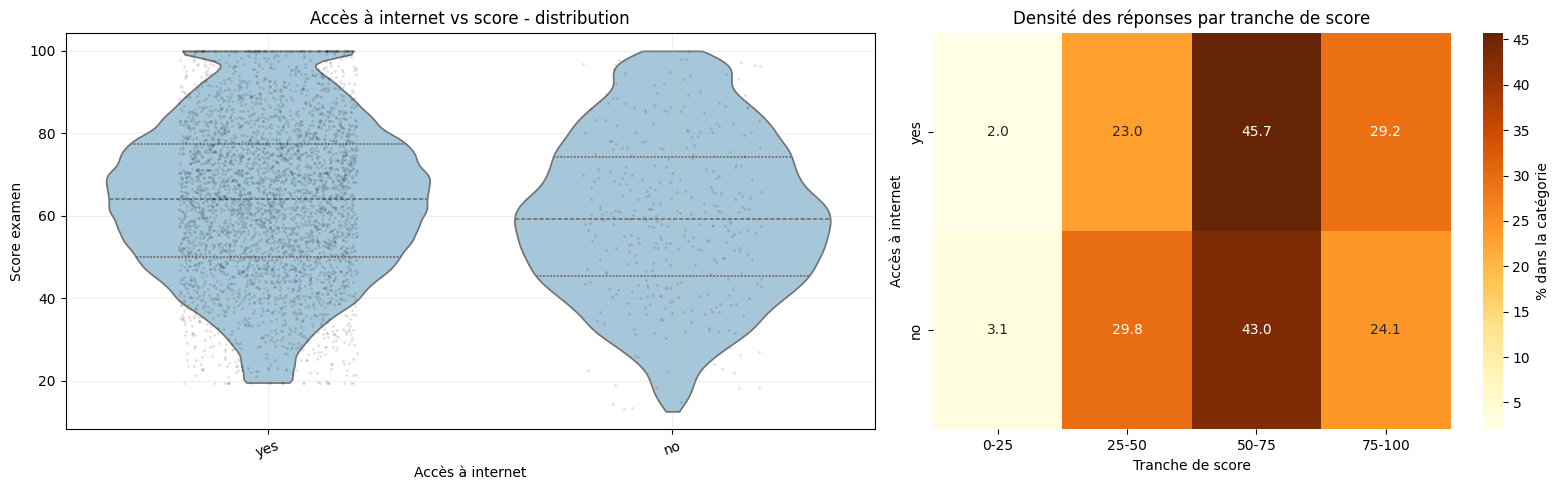

In [14]:
# accès_internet vs score
plot_categorical_score_density(
    X_train["accès_internet"],
    y_train,
    "Accès à internet",
    "acces_internet_vs_score_density.png",
)


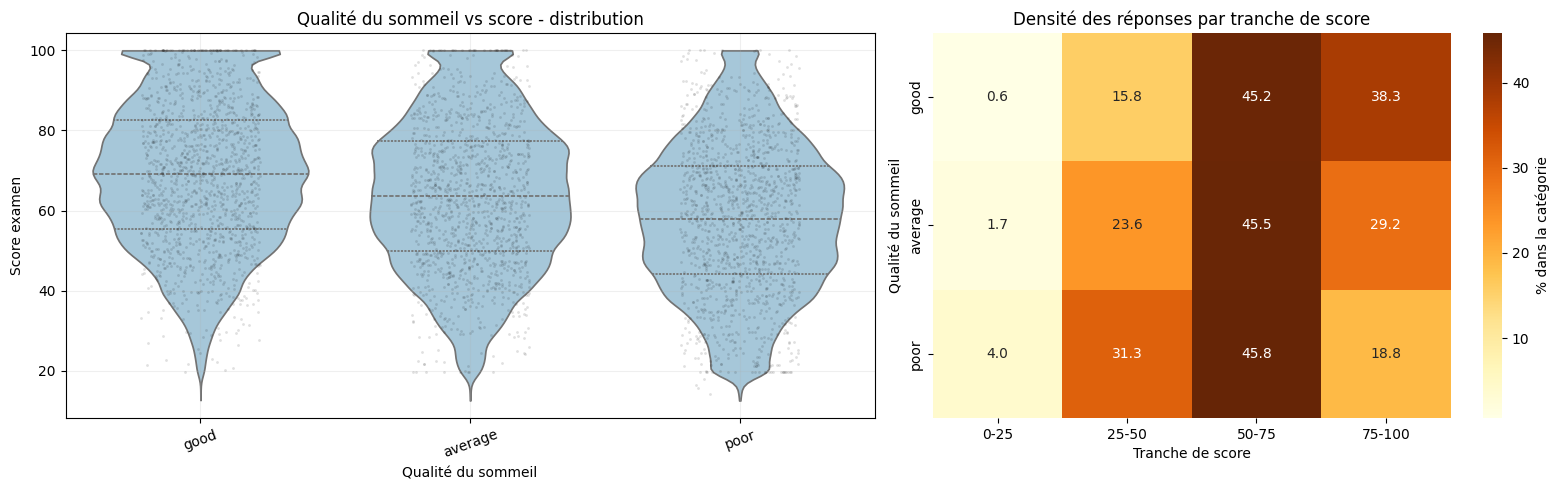

In [15]:
# qualité_sommeil vs score
plot_categorical_score_density(
    X_train["qualité_sommeil"],
    y_train,
    "Qualité du sommeil",
    "qualite_sommeil_vs_score_density.png",
)


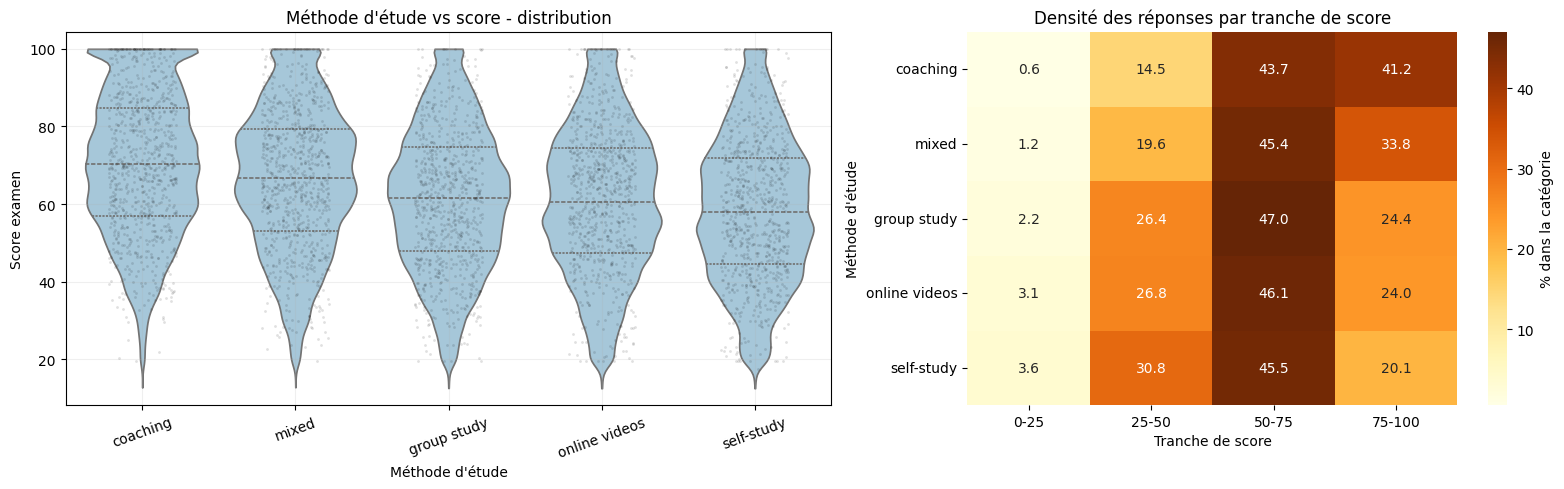

In [16]:
# méthode_etude vs score
plot_categorical_score_density(
    X_train["méthode_etude"],
    y_train,
    "Méthode d'étude",
    "methode_etude_vs_score_density.png",
)


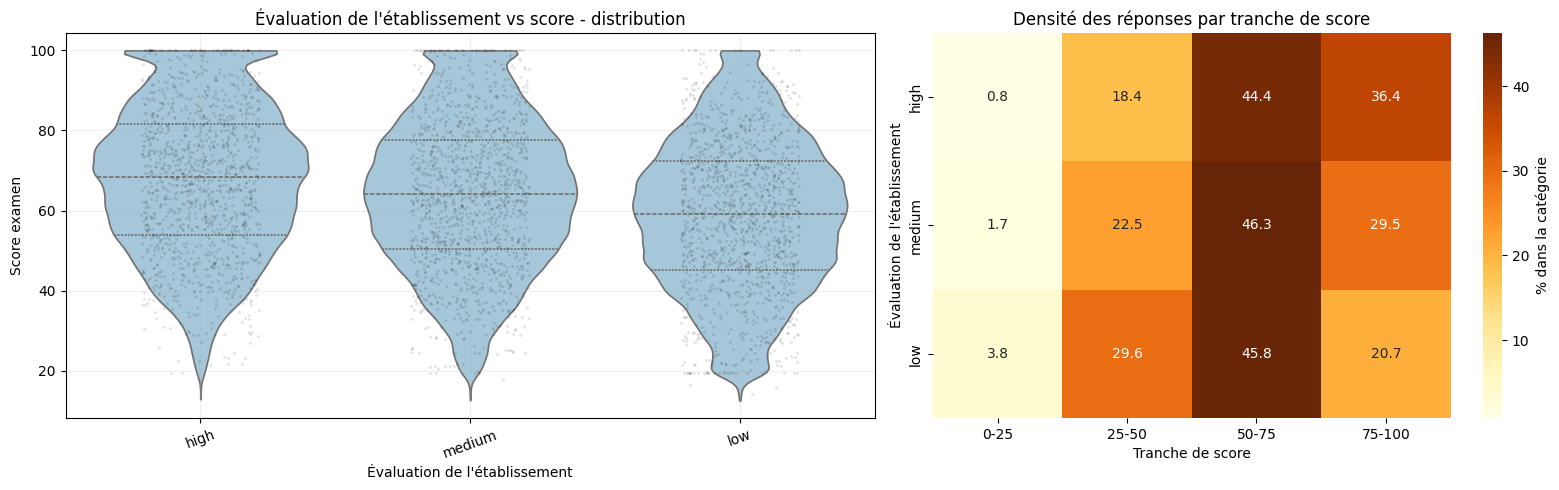

In [17]:
# évaluation_établissement vs score
plot_categorical_score_density(
    X_train["évaluation_établissement"],
    y_train,
    "Évaluation de l'établissement",
    "evaluation_etablissement_vs_score_density.png",
)


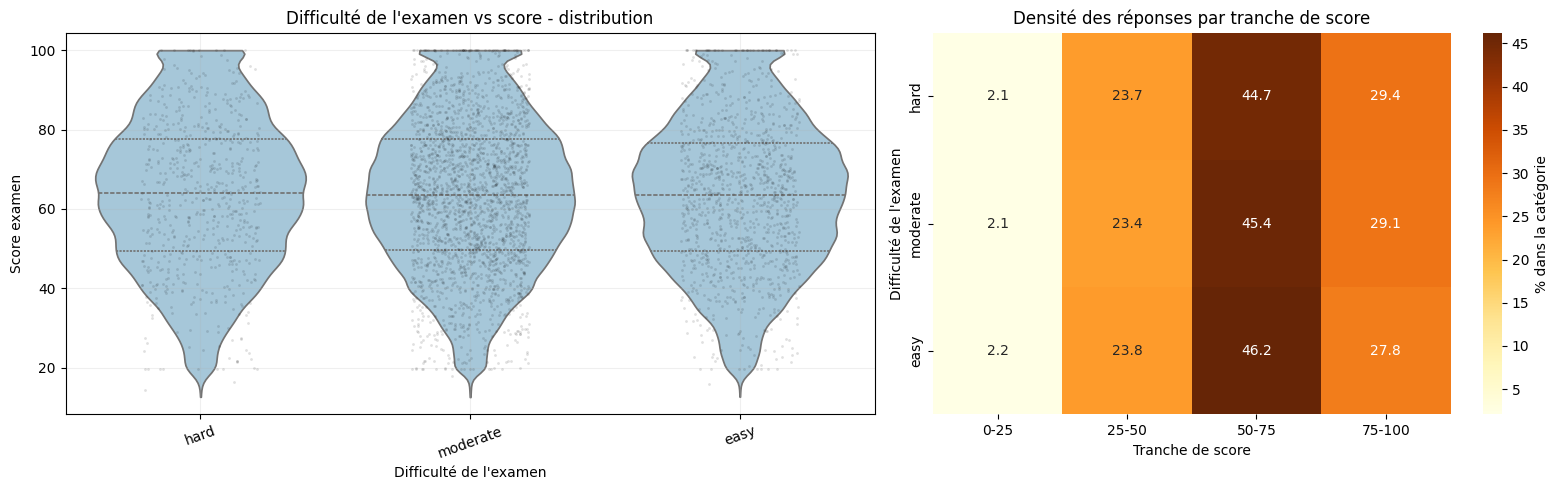

In [18]:
# difficulté_examen vs score
plot_categorical_score_density(
    X_train["difficulté_examen"],
    y_train,
    "Difficulté de l'examen",
    "difficulte_examen_vs_score_density.png",
)


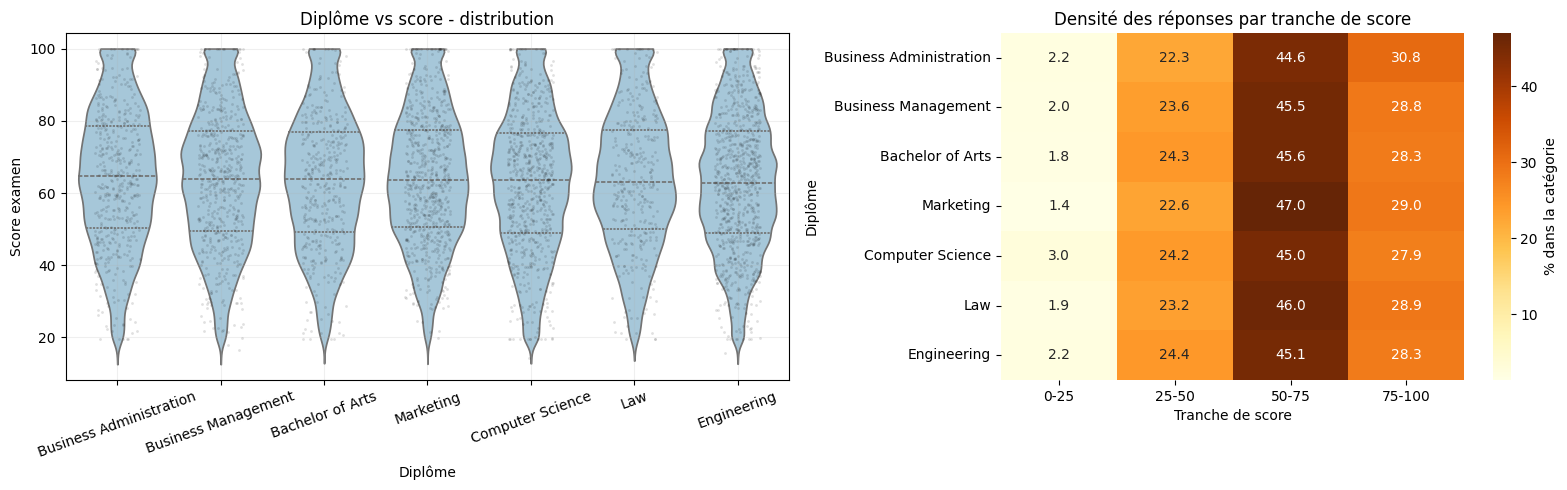

In [19]:
# diplome vs score
plot_categorical_score_density(
    X_train["diplôme"],
    y_train,
    "Diplôme",
    "diplôme_vs_score_density.png",
)

### matrice de coorélation

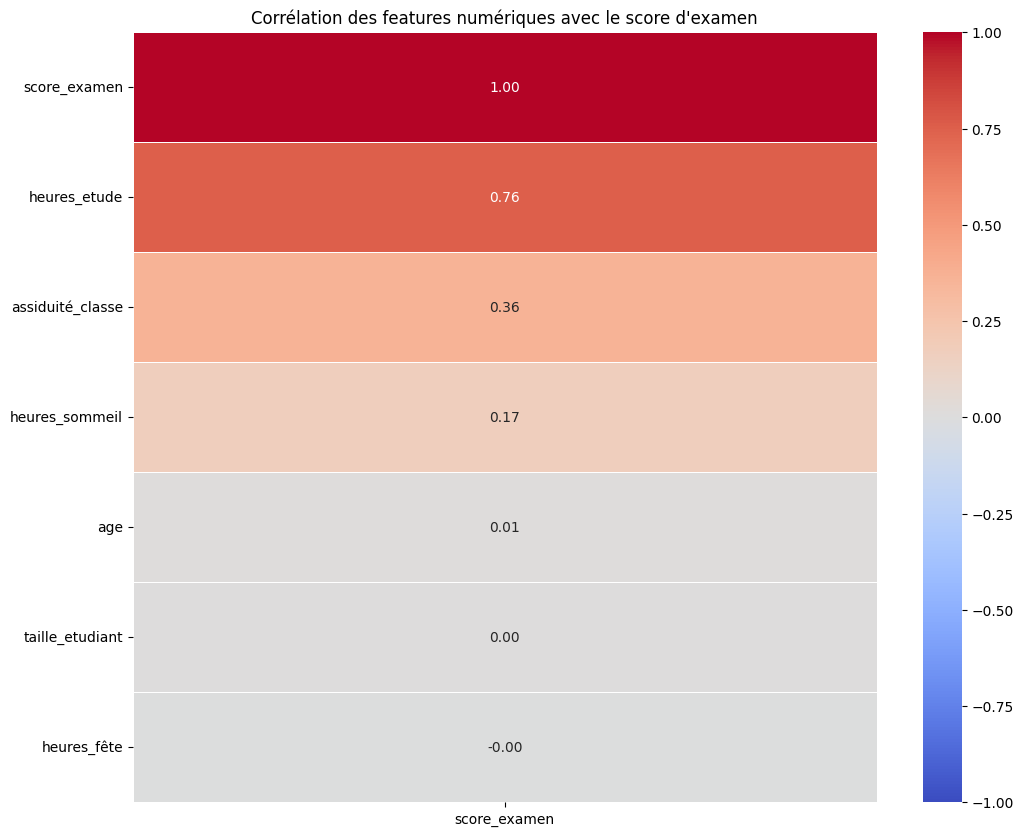

In [20]:
# Corrélations entre les features numériques et le score
numeric_corr_data = (
    model_data
    .drop(columns=[id_col], errors="ignore")
    .select_dtypes(include=np.number)
)

corr_with_target = (
    numeric_corr_data
    .corr(numeric_only=True)[[target_col]]
    .sort_values(by=target_col, ascending=False)
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_with_target,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Corrélation des features numériques avec le score d'examen")
plt.savefig("../Graph/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### MI

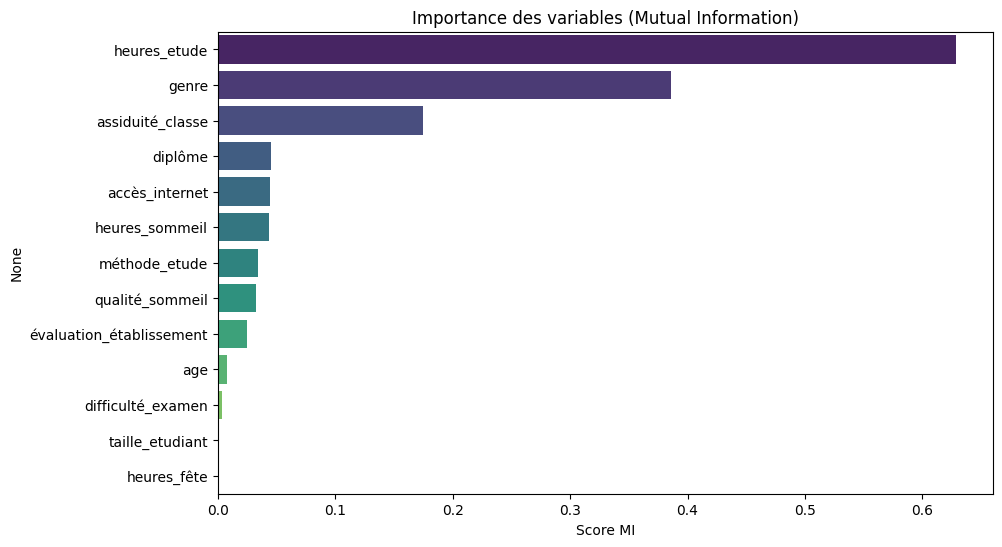

In [21]:
X_mi = X_train.copy()

for col in X_mi.select_dtypes(include='number').columns:
    X_mi[col] = X_mi[col].fillna(X_mi[col].median())
 
for col in X_mi.select_dtypes(include='object').columns:
    X_mi[col], _ = X_mi[col].factorize()

discrete_features = X_mi.dtypes == int

mi_scores = mutual_info_regression(X_mi, y_train, discrete_features=discrete_features, random_state=0)
mi_scores_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index, palette='viridis')
plt.title("Importance des variables (Mutual Information)")
plt.xlabel("Score MI")
plt.savefig("../Graph/mi_scores.png")
plt.show()


In [22]:
print("Mutual Information Scores:", mi_scores_series)

Mutual Information Scores: heures_etude                0.628489
genre                       0.385986
assiduité_classe            0.174912
diplôme                     0.044910
accès_internet              0.044489
heures_sommeil              0.043740
méthode_etude               0.034321
qualité_sommeil             0.032636
évaluation_établissement    0.024719
age                         0.007982
difficulté_examen           0.003933
taille_etudiant             0.000842
heures_fête                 0.000000
dtype: float64


Features numériques utilisées pour la PCA (6) :
['age', 'heures_etude', 'assiduité_classe', 'heures_sommeil', 'heures_fête', 'taille_etudiant']


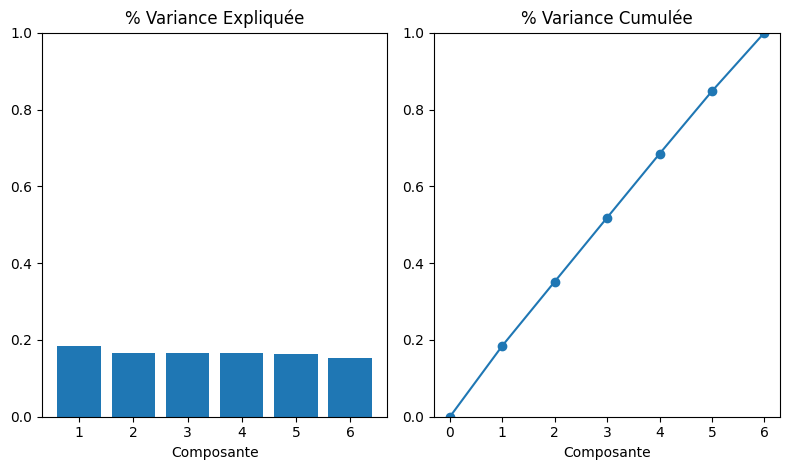


Variance expliquée par composante :
  PC1: 18.5%  (cumulé: 18.5%)
  PC2: 16.7%  (cumulé: 35.2%)
  PC3: 16.7%  (cumulé: 51.9%)
  PC4: 16.6%  (cumulé: 68.5%)
  PC5: 16.3%  (cumulé: 84.8%)
  PC6: 15.2%  (cumulé: 100.0%)


In [23]:
# --- 1. Analyse de la variance expliquée (PCA sans restriction) ---

def plot_variance(pca, width=8, dpi=100):
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(xlabel="Composante", title="% Variance Expliquée", ylim=(0.0, 1.0))
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(xlabel="Composante", title="% Variance Cumulée", ylim=(0.0, 1.0))
    fig.set(figwidth=width, dpi=dpi)
    plt.tight_layout()
    return axs

# Garder uniquement les features numériques CONTINUES pour la PCA.
# Les colonnes catégorielles encodées par factorize() donnent des codes
# arbitraires (0, 1, 2...) sans relation de distance : la PCA les interpréterait
# comme des quantités continues, ce qui fausse les composantes.
numeric_features = X_train.select_dtypes(include='number').columns.tolist()
X_numeric = X_mi[numeric_features]
feature_names = X_numeric.columns  # utilisé dans toutes les cellules PCA suivantes

print(f"Features numériques utilisées pour la PCA ({len(numeric_features)}) :")
print(numeric_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# PCA sans restriction pour voir toutes les composantes
pca_full = PCA()
pca_full.fit(X_scaled)

plot_variance(pca_full)
plt.savefig("../Graph/pca_variance.png")
plt.show()

print("\nVariance expliquée par composante :")
for i, evr in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {evr*100:.1f}%  (cumulé: {np.cumsum(pca_full.explained_variance_ratio_)[i]*100:.1f}%)")

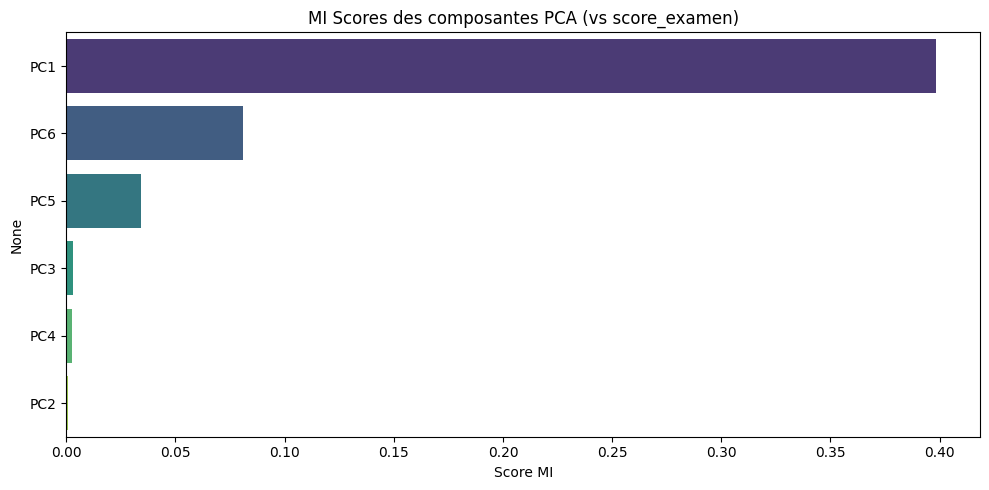

PC1    0.398571
PC6    0.080966
PC5    0.034016
PC3    0.003012
PC4    0.002452
PC2    0.000921
Name: MI Score, dtype: float64


In [24]:
# --- 2. MI Scores des composantes PCA ---
# Quelles composantes sont les plus prédictives de score_examen ?

X_pca_full = pca_full.transform(X_scaled)
component_names = [f"PC{i+1}" for i in range(X_pca_full.shape[1])]
X_pca_df = pd.DataFrame(X_pca_full, columns=component_names, index=X_mi.index)

mi_scores_pca = mutual_info_regression(X_pca_df, y_train, discrete_features=False, random_state=0)
mi_scores_pca = pd.Series(mi_scores_pca, name="MI Score", index=component_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=mi_scores_pca.values, y=mi_scores_pca.index, palette="viridis")
plt.title("MI Scores des composantes PCA (vs score_examen)")
plt.xlabel("Score MI")
plt.tight_layout()
plt.savefig("../Graph/pca_mi_scores.png")
plt.show()

print(mi_scores_pca)

In [25]:
# --- 3. Analyse des loadings et feature engineering ---

# feature_names est défini dans la cellule PCA (uniquement les colonnes numériques)
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=component_names,
    index=feature_names
)

# Sélectionner uniquement les composantes qui atteignent 95% de variance cumulée.
# Hardcoder à 4 était arbitraire et cachait des composantes potentiellement
# informatives révélées par les MI scores ci-dessus.
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_sig = int(np.searchsorted(cumvar, 0.95)) + 1
n_sig = min(n_sig, len(component_names))

print(f"Affichage des {n_sig} composantes significatives (>= 95% variance cumulée)")
display(
    loadings.iloc[:, :n_sig]
    .style.background_gradient(cmap="coolwarm", axis=None)
    .format("{:.3f}")
)

# Identifier le contraste dominant dans PC1 (feature la plus positive vs la plus négative)
pc1_loadings = loadings["PC1"].sort_values()
top_negative = pc1_loadings.head(1).index[0]
top_positive = pc1_loadings.tail(1).index[0]

print(f"\nContraste PC1 : '{top_positive}' (positif) vs '{top_negative}' (négatif)")

# Créer une feature ratio inspirée du contraste PC1
ratio_col = f"ratio_{top_positive}_vs_{top_negative}"
X_mi[ratio_col] = X_mi[top_positive] / (X_mi[top_negative].abs() + 1e-6)

print(f"Nouvelle feature créée : {ratio_col}")
print(X_mi[ratio_col].describe())

# Vérifier l'utilité de cette feature avec MI
mi_ratio = mutual_info_regression(
    X_mi[[ratio_col]], y_train, discrete_features=False, random_state=0
)
print(f"\nMI Score de '{ratio_col}' : {mi_ratio[0]:.4f}")

Affichage des 6 composantes significatives (>= 95% variance cumulée)


,PC1,PC2,PC3,PC4,PC5,PC6
age,0.095,-0.063,0.793,-0.592,-0.088,-0.008
heures_etude,0.653,0.022,-0.054,0.050,-0.198,0.727
assiduité_classe,0.625,0.040,-0.065,0.075,-0.376,-0.676
heures_sommeil,0.417,-0.085,-0.006,-0.063,0.894,-0.124
heures_fête,0.001,-0.699,0.389,0.599,-0.022,0.002
taille_etudiant,0.005,0.706,0.461,0.528,0.106,0.001



Contraste PC1 : 'heures_etude' (positif) vs 'heures_fête' (négatif)
Nouvelle feature créée : ratio_heures_etude_vs_heures_fête
count    5.040000e+05
mean     7.294136e+04
std      6.206941e+05
min      6.153846e-03
25%      5.028571e-01
50%      1.002000e+00
75%      1.752500e+00
max      7.910000e+06
Name: ratio_heures_etude_vs_heures_fête, dtype: float64

MI Score de 'ratio_heures_etude_vs_heures_fête' : 0.3245


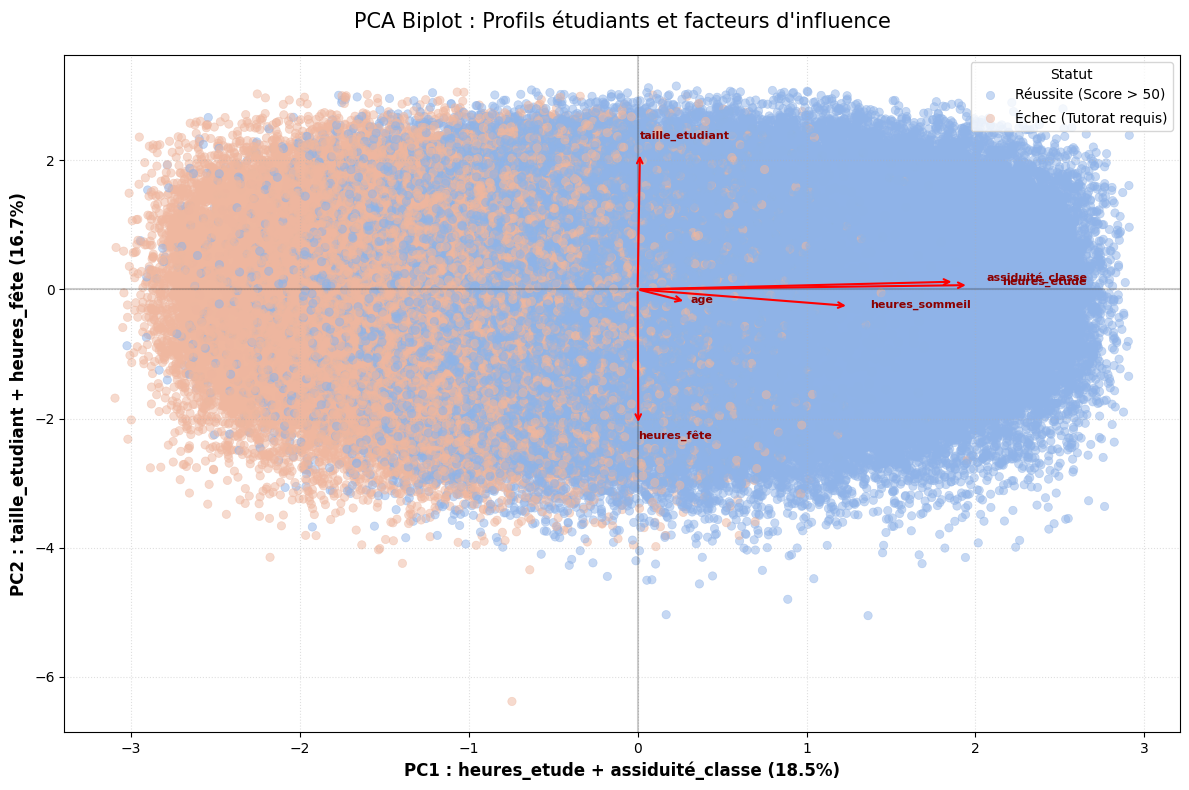

In [26]:
# --- 4. Vrai Biplot PCA (scatter + flèches des loadings) ---
# Refit PCA à 2 composantes pour la visualisation 2D

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

loadings_2d = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1", "PC2"],
    index=feature_names
)

def get_axis_description(ldf, pc_name, top_n=2):
    top_features = ldf[pc_name].abs().sort_values(ascending=False).head(top_n).index.tolist()
    return " + ".join(top_features)

label_pc1 = f"PC1 : {get_axis_description(loadings_2d, 'PC1')} ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)"
label_pc2 = f"PC2 : {get_axis_description(loadings_2d, 'PC2')} ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)"

status = (y_train < 50).map({
    False: "Réussite (Score > 50)",
    True: "Échec (Tutorat requis)"
})
status_palette = {
    "Réussite (Score > 50)": "#8fb3e8",
    "Échec (Tutorat requis)": "#efb79f"
}

fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    x=X_pca_2d[:, 0],
    y=X_pca_2d[:, 1],
    hue=status,
    hue_order=["Réussite (Score > 50)", "Échec (Tutorat requis)"],
    palette=status_palette,
    alpha=0.5,
    edgecolor=None,
    ax=ax
)

# Flèches des loadings (ce qui rend le biplot "vrai")
scale = 3
for feature in feature_names:
    fx = loadings_2d.loc[feature, "PC1"] * scale
    fy = loadings_2d.loc[feature, "PC2"] * scale
    ax.annotate(
        "",
        xy=(fx, fy),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color="red", lw=1.5)
    )
    ax.text(fx * 1.1, fy * 1.1, feature, fontsize=8, color="darkred", fontweight="bold")

ax.axvline(0, color="black", linestyle="-", alpha=0.2)
ax.axhline(0, color="black", linestyle="-", alpha=0.2)
ax.set_title("PCA Biplot : Profils étudiants et facteurs d'influence", fontsize=15, pad=20)
ax.set_xlabel(label_pc1, fontsize=12, fontweight="bold")
ax.set_ylabel(label_pc2, fontsize=12, fontweight="bold")
ax.legend(title="Statut", loc="upper right")
ax.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig("../Graph/pca_biplot.png")
plt.show()

## Data encoding et scaling 


In [27]:
# check for missing values in the selected features
cols_with_missing = [col for col in X.columns
                     if X[col].isnull().any()]
print("Colonnes avec valeurs manquantes :", cols_with_missing)
# nombre de valeurs manquantes par colonne
missing_counts = X[cols_with_missing].isnull().sum()
print("\nNombre de valeurs manquantes par colonne :")
print(missing_counts)
# pourcentage de valeurs manquantes par colonne
missing_percent = (missing_counts / len(X)) * 100
print("\nPourcentage de valeurs manquantes par colonne :")
print(missing_percent)



Colonnes avec valeurs manquantes : ['heures_etude', 'accès_internet', 'méthode_etude']

Nombre de valeurs manquantes par colonne :
heures_etude      18900
accès_internet    63000
méthode_etude     44100
dtype: int64

Pourcentage de valeurs manquantes par colonne :
heures_etude       3.0
accès_internet    10.0
méthode_etude      7.0
dtype: float64


## Version pipeline train / validation / test

Cette section refait le split et le preprocessing avec un pipeline, puis utilise `validation` pour comparer les modèles et `test` uniquement pour l'évaluation finale.

In [28]:


X_pipe = data.drop(["score_examen", "id"], axis=1)
y_pipe = data["score_examen"]

X_train_full_pipe, X_test_pipe, y_train_full_pipe, y_test_pipe = train_test_split(
    X_pipe,
    y_pipe,
    test_size=0.2,
    random_state=0,
)

X_train_pipe, X_val_pipe, y_train_pipe, y_val_pipe = train_test_split(
    X_train_full_pipe,
    y_train_full_pipe,
    test_size=0.2,
    random_state=0,
)

features = [
    "heures_etude",
    "genre",
    "assiduité_classe",
    "diplôme",
    "accès_internet",
    "heures_sommeil",
    "méthode_etude",
    "qualité_sommeil",
    "évaluation_établissement",
    "age",
    "difficulté_examen",
]
ratio_col = "ratio_heures_etude_vs_heures_fête"
missing_indicator_cols = ["accès_internet_was_missing", "méthode_etude_was_missing"]
ordinal_features = ["genre", "accès_internet", "évaluation_établissement", "difficulté_examen", "qualité_sommeil"]
one_hot_features = ["diplôme", "méthode_etude"]
numeric_features = ["heures_etude", "assiduité_classe", "heures_sommeil", "age", ratio_col]
selected_features = numeric_features + ordinal_features + one_hot_features + missing_indicator_cols

def add_selected_features(df):
    X = df.copy()
    X[ratio_col] = X["heures_etude"] / (X["heures_fête"].abs() + 1e-6)
    for col in ("accès_internet", "méthode_etude"):
        X[f"{col}_was_missing"] = X[col].isnull().astype(int)
    return X[selected_features]

preprocessing_pipeline = Pipeline([
    ("feature_builder", FunctionTransformer(add_selected_features, validate=False)),
    (
        "preprocessor",
        ColumnTransformer(
            transformers=[
                (
                    "num",
                    Pipeline([
                        ("imputer", SimpleImputer(strategy="mean")),
                    ]),
                    numeric_features,
                ),
                (
                    "ord",
                    Pipeline([
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                    ]),
                    ordinal_features,
                ),
                (
                    "onehot",
                    Pipeline([
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                    ]),
                    one_hot_features,
                ),
                ("flags", "passthrough", missing_indicator_cols),
            ],
            remainder="drop",
            sparse_threshold=0,
            verbose_feature_names_out=False,
        ),
    ),
])

X_train_processed = preprocessing_pipeline.fit_transform(X_train_pipe)
X_val_processed = preprocessing_pipeline.transform(X_val_pipe)
X_test_processed = preprocessing_pipeline.transform(X_test_pipe)

processed_feature_names = preprocessing_pipeline.named_steps["preprocessor"].get_feature_names_out()

train_processed_df = pd.DataFrame(X_train_processed, columns=processed_feature_names, index=X_train_pipe.index)
val_processed_df = pd.DataFrame(X_val_processed, columns=processed_feature_names, index=X_val_pipe.index)
test_processed_df = pd.DataFrame(X_test_processed, columns=processed_feature_names, index=X_test_pipe.index)

print(f"Taille train : {X_train_pipe.shape[0]}")
print(f"Taille validation : {X_val_pipe.shape[0]}")
print(f"Taille test : {X_test_pipe.shape[0]}")
display(train_processed_df.head())


Taille train : 403200
Taille validation : 100800
Taille test : 126000


,heures_etude,assiduité_classe,heures_sommeil,age,ratio_heures_etude_vs_heures_fête,genre,accès_internet,évaluation_établissement,difficulté_examen,qualité_sommeil,...,diplôme_Engineering,diplôme_Law,diplôme_Marketing,méthode_etude_coaching,méthode_etude_group study,méthode_etude_mixed,méthode_etude_online videos,méthode_etude_self-study,accès_internet_was_missing,méthode_etude_was_missing
135960,6.10,82.9,9.6,23.0,2.033333,1.0,1.0,2.0,2.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
519118,0.39,47.6,6.8,19.0,0.195000,0.0,1.0,1.0,2.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
82696,7.75,94.0,5.2,18.0,3.874998,0.0,1.0,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
150827,4.39,59.7,7.7,23.0,1.463333,1.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
507161,5.31,83.7,7.5,18.0,1.769999,1.0,1.0,1.0,2.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [29]:



experiments_dir = Path("Projet/experiments") if Path("Projet").exists() else Path("experiments")
experiments_dir.mkdir(parents=True, exist_ok=True)
split_path = experiments_dir / "fixed_split.json"
metrics_path = experiments_dir / "metrics_history.json"
current_run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

def save_fixed_split(train_ids, val_ids, test_ids):
    split_payload = {
        "train_ids": [int(x) for x in train_ids],
        "val_ids": [int(x) for x in val_ids],
        "test_ids": [int(x) for x in test_ids],
    }
    with open(split_path, "w", encoding="utf-8") as f:
        json.dump(split_payload, f, ensure_ascii=False, indent=2)

def load_fixed_split():
    with open(split_path, "r", encoding="utf-8") as f:
        return json.load(f)

if split_path.exists():
    saved_split = load_fixed_split()
    train_ids_set = set(saved_split["train_ids"])
    val_ids_set = set(saved_split["val_ids"])
    test_ids_set = set(saved_split["test_ids"])

    train_df = model_data[model_data[id_col].isin(train_ids_set)].copy()
    val_df = model_data[model_data[id_col].isin(val_ids_set)].copy()
    test_df = model_data[model_data[id_col].isin(test_ids_set)].copy()

    expected_total = len(saved_split["train_ids"]) + len(saved_split["val_ids"]) + len(saved_split["test_ids"])
    actual_total = len(train_df) + len(val_df) + len(test_df)
    if actual_total != expected_total:
        raise ValueError("Le split sauvegardé ne correspond plus au dataset actuel. Supprime fixed_split.json pour recréer un split.")

    print(f"Split rechargé depuis : {split_path}")
else:
    train_full_df, test_df = train_test_split(
        model_data,
        test_size=0.2,
        random_state=0,
    )
    train_df, val_df = train_test_split(
        train_full_df,
        test_size=0.2,
        random_state=0,
    )
    save_fixed_split(train_df[id_col], val_df[id_col], test_df[id_col])
    print(f"Nouveau split sauvegardé dans : {split_path}")

X_train_pipe = train_df.drop([target_col, id_col], axis=1)
X_val_pipe = val_df.drop([target_col, id_col], axis=1)
X_test_pipe = test_df.drop([target_col, id_col], axis=1)
y_train_pipe = train_df[target_col]
y_val_pipe = val_df[target_col]
y_test_pipe = test_df[target_col]
train_ids_pipe = train_df[id_col]
val_ids_pipe = val_df[id_col]
test_ids_pipe = test_df[id_col]

X_train_processed = preprocessing_pipeline.fit_transform(X_train_pipe)
X_val_processed = preprocessing_pipeline.transform(X_val_pipe)
X_test_processed = preprocessing_pipeline.transform(X_test_pipe)

processed_feature_names = preprocessing_pipeline.named_steps["preprocessor"].get_feature_names_out()
train_processed_df = pd.DataFrame(X_train_processed, columns=processed_feature_names, index=X_train_pipe.index)
val_processed_df = pd.DataFrame(X_val_processed, columns=processed_feature_names, index=X_val_pipe.index)
test_processed_df = pd.DataFrame(X_test_processed, columns=processed_feature_names, index=X_test_pipe.index)

def _sanitize_model_name(model_name):
    return model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")

def _band_metrics_to_dict(mae_bands_df, prefix):
    metrics = {}
    for _, row in mae_bands_df.iterrows():
        tranche = str(row["tranche"]).replace("-", "_").replace(" ", "")
        metrics[f"{prefix}_n_{tranche}"] = int(row["n"])
        metrics[f"{prefix}_mae_{tranche}"] = float(row["mae"]) if pd.notna(row["mae"]) else np.nan
    return metrics

def log_experiment(model_name, params, mae_val, mae_test, mae_bands_val, mae_bands_test, artifacts=None, run_id=None):
    run_id = run_id or current_run_id
    row = {
        "run_id": run_id,
        "logged_at": datetime.now().isoformat(timespec="seconds"),
        "model": model_name,
        "params": json.dumps(params, ensure_ascii=False),
        "mae_val": float(mae_val),
        "mae_test": float(mae_test),
        "artifacts": json.dumps(artifacts or {}, ensure_ascii=False),
    }
    row.update(_band_metrics_to_dict(mae_bands_val, "val"))
    row.update(_band_metrics_to_dict(mae_bands_test, "test"))

    if metrics_path.exists():
        with open(metrics_path, "r", encoding="utf-8") as f:
            metrics_history = json.load(f)
    else:
        metrics_history = []

    metrics_history.append(row)

    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics_history, f, ensure_ascii=False, indent=2)

    return metrics_history

print(f"Run ID courant : {current_run_id}")
print(f"Historique des métriques : {metrics_path}")
print(f"Taille train : {X_train_pipe.shape[0]}")
print(f"Taille validation : {X_val_pipe.shape[0]}")
print(f"Taille test : {X_test_pipe.shape[0]}")


Split rechargé depuis : experiments/fixed_split.json
Run ID courant : 20260506_113332
Historique des métriques : experiments/metrics_history.json
Taille train : 403200
Taille validation : 100800
Taille test : 126000


In [30]:
# test su meuilleur modèle de base (Decision Tree) avec pipeline complet


candidate_max_leaf_nodes = [5, 10, 25, 50, 100, 250, 500, 1000, 1200, 1500, 2000, 2100, 2200, 2300, 2400, 2500]
cv_results = {}

for max_leaf_nodes in candidate_max_leaf_nodes:
    tree_pipeline = Pipeline([
        ("preprocessing", preprocessing_pipeline),
        ("model", DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=1)),
    ])

    scores = -1 * cross_val_score(
        tree_pipeline,
        X_train_pipe,
        y_train_pipe,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    cv_results[max_leaf_nodes] = scores.mean()
    print(f"{max_leaf_nodes}: MAE CV moyen = {scores.mean():.4f} | std = {scores.std():.4f}")

best_tree_size = min(cv_results, key=cv_results.get)
print(f"\nMeilleur max_leaf_nodes: {best_tree_size}")
print(f"Meilleur MAE CV: {cv_results[best_tree_size]:.4f}")


5: MAE CV moyen = 10.3089 | std = 0.0240
10: MAE CV moyen = 9.6074 | std = 0.0186
25: MAE CV moyen = 9.1009 | std = 0.0247
50: MAE CV moyen = 8.7676 | std = 0.0237
100: MAE CV moyen = 8.4902 | std = 0.0194
250: MAE CV moyen = 8.1853 | std = 0.0239
500: MAE CV moyen = 7.9940 | std = 0.0234
1000: MAE CV moyen = 7.8610 | std = 0.0236
1200: MAE CV moyen = 7.8318 | std = 0.0243
1500: MAE CV moyen = 7.8067 | std = 0.0229
2000: MAE CV moyen = 7.7888 | std = 0.0194
2100: MAE CV moyen = 7.7880 | std = 0.0183
2200: MAE CV moyen = 7.7869 | std = 0.0174
2300: MAE CV moyen = 7.7868 | std = 0.0169
2400: MAE CV moyen = 7.7864 | std = 0.0165
2500: MAE CV moyen = 7.7867 | std = 0.0169

Meilleur max_leaf_nodes: 2400
Meilleur MAE CV: 7.7864


In [31]:
# cross validation random forest
"""n_estimators =[50, 100, 200, 500]
scores_rf = {}

for n in n_estimators:
    rf_cross_pipeline = Pipeline([
        ("preprocessing", preprocessing_pipeline),
        ("model", RandomForestRegressor(
            n_estimators=n,
            random_state=1,
            n_jobs=6,
        )),
    ])
    rf_cv_scores = -1 * cross_val_score(
        rf_cross_pipeline,
        X_train_pipe,
        y_train_pipe,
        cv=5,
        scoring="neg_mean_absolute_error"
    )
    scores_rf[n] = rf_cv_scores.mean()
    print(f"n_estimators={n}: MAE CV moyen = {rf_cv_scores.mean():.4f} | std = {rf_cv_scores.std():.4f}")

best_n_estimators = min(scores_rf, key=scores_rf.get)
print(f"Random Forest - Meilleur n_estimators = {best_n_estimators} | MAE CV moyen = {scores_rf[best_n_estimators]:.4f}")"""

'n_estimators =[50, 100, 200, 500]\nscores_rf = {}\n\nfor n in n_estimators:\n    rf_cross_pipeline = Pipeline([\n        ("preprocessing", preprocessing_pipeline),\n        ("model", RandomForestRegressor(\n            n_estimators=n,\n            random_state=1,\n            n_jobs=6,\n        )),\n    ])\n    rf_cv_scores = -1 * cross_val_score(\n        rf_cross_pipeline,\n        X_train_pipe,\n        y_train_pipe,\n        cv=5,\n        scoring="neg_mean_absolute_error"\n    )\n    scores_rf[n] = rf_cv_scores.mean()\n    print(f"n_estimators={n}: MAE CV moyen = {rf_cv_scores.mean():.4f} | std = {rf_cv_scores.std():.4f}")\n\nbest_n_estimators = min(scores_rf, key=scores_rf.get)\nprint(f"Random Forest - Meilleur n_estimators = {best_n_estimators} | MAE CV moyen = {scores_rf[best_n_estimators]:.4f}")'

MAE test naïf : 15.5901


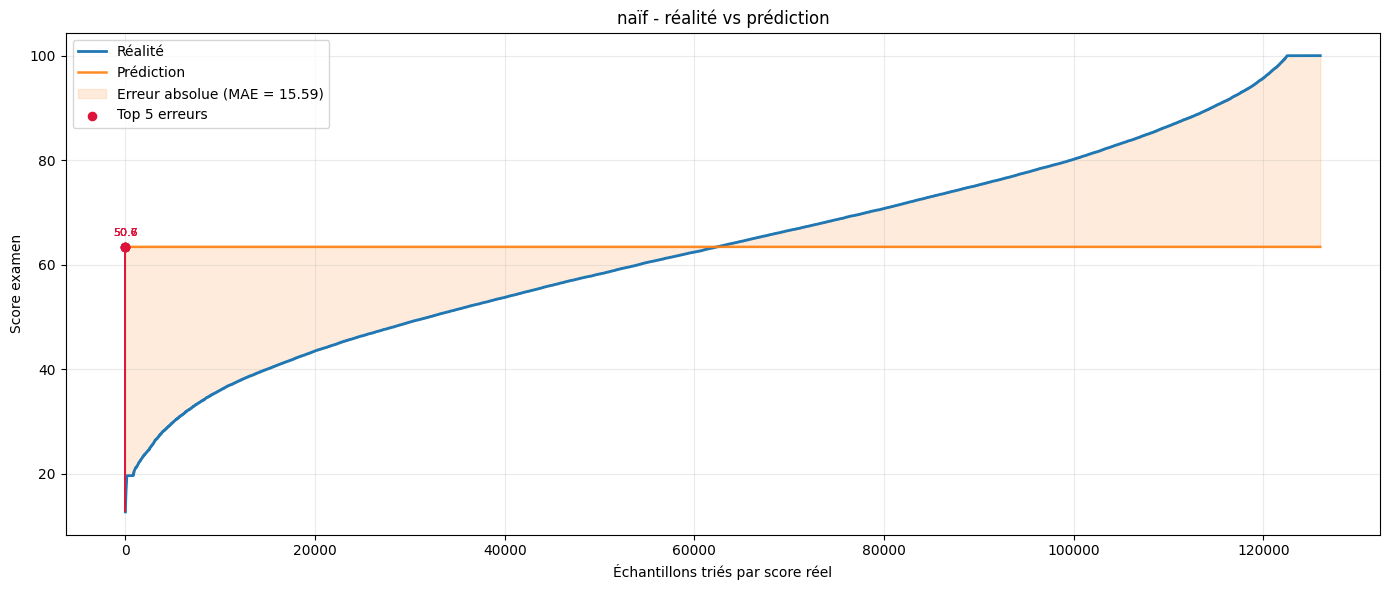

,sample_id,reel,pred,erreur_abs
0,111087,12.66,63.4,50.74
1,47044,12.68,63.4,50.72
2,18290,12.75,63.4,50.65
3,38931,12.75,63.4,50.65
4,26987,12.76,63.4,50.64


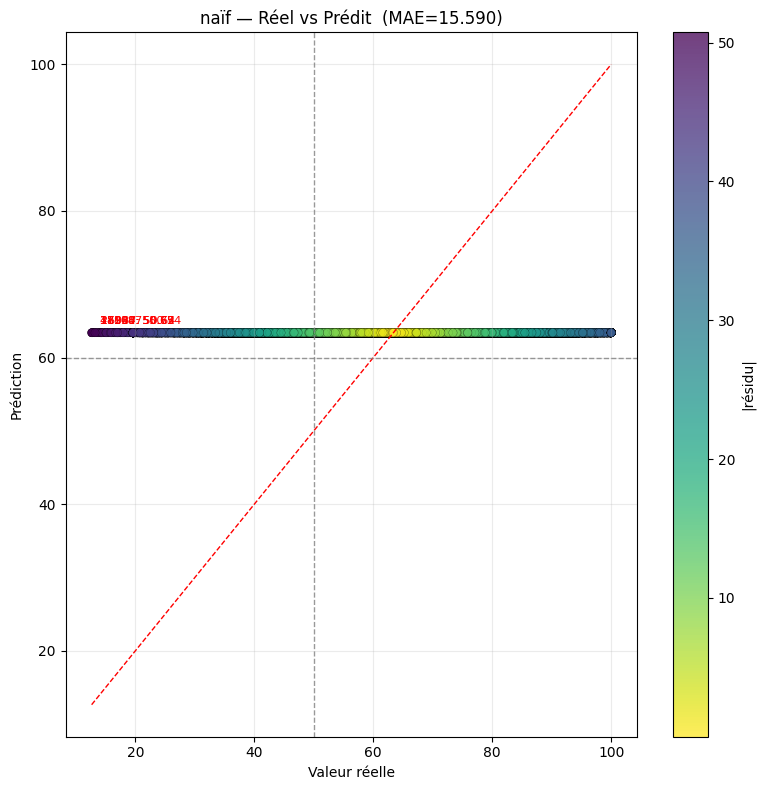

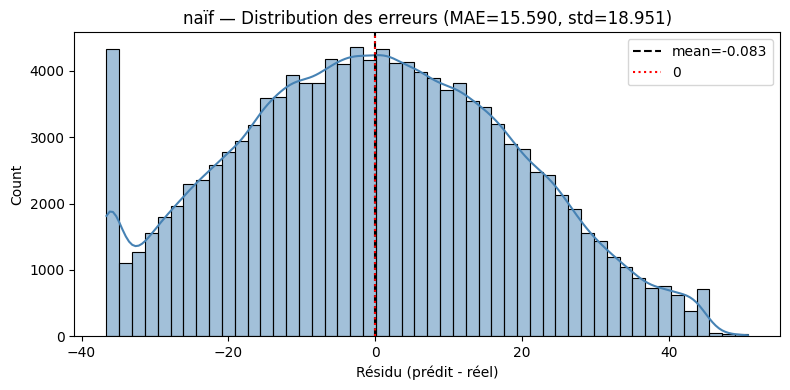

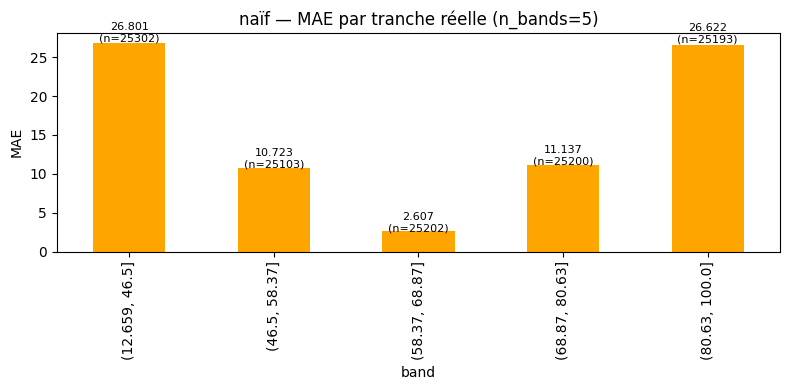

,mae,n
band,,
"(12.659, 46.5]",26.800777,25302
"(46.5, 58.37]",10.723486,25103
"(58.37, 68.87]",2.607230,25202
"(68.87, 80.63]",11.136514,25200
"(80.63, 100.0]",26.622266,25193


In [32]:
naive_mae_test = mean_absolute_error(y_test_pipe, np.repeat(y_train_pipe.mean(), len(y_test_pipe)))
print(f"MAE test naïf : {naive_mae_test:.4f}")
plot_mae_overlay(y_test_pipe, np.repeat(y_train_pipe.mean(), len(y_test_pipe)), "naïf", "naive_mae_overlay.png")
plot_preds_vs_true(y_test_pipe, np.repeat(y_train_pipe.mean(), len(y_test_pipe)), name="naïf")
plot_error_distribution(y_test_pipe, np.repeat(y_train_pipe.mean(), len(y_test_pipe)), name="naïf")
plot_error_by_true_band(y_test_pipe, np.repeat(y_train_pipe.mean(), len(y_test_pipe)), name="naïf")

MAE validation du modèle Decision Tree : 7.7773
  tranche      n        mae
0    0-25   2148  12.817568
1   25-90  89525   7.452791
2  90-100   9127   9.773663
MAE test du modèle Decision Tree : 7.7379
  tranche       n        mae
0    0-25    2610  12.704168
1   25-90  111870   7.429593
2  90-100   11520   9.606541


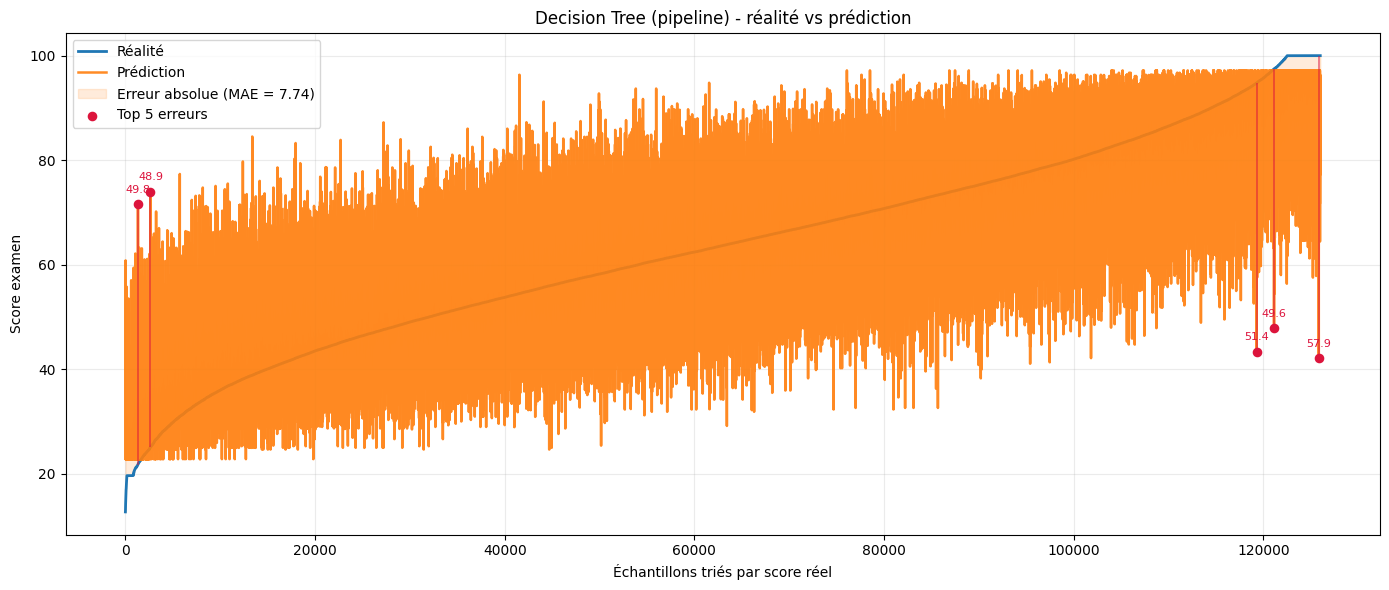

,sample_id,reel,pred,erreur_abs
125844,46794,100.00,42.10,57.90
119287,4736,94.77,43.36,51.41
1324,24922,21.72,71.54,49.82
121123,52760,97.44,47.84,49.60
2645,91442,25.10,73.98,48.88


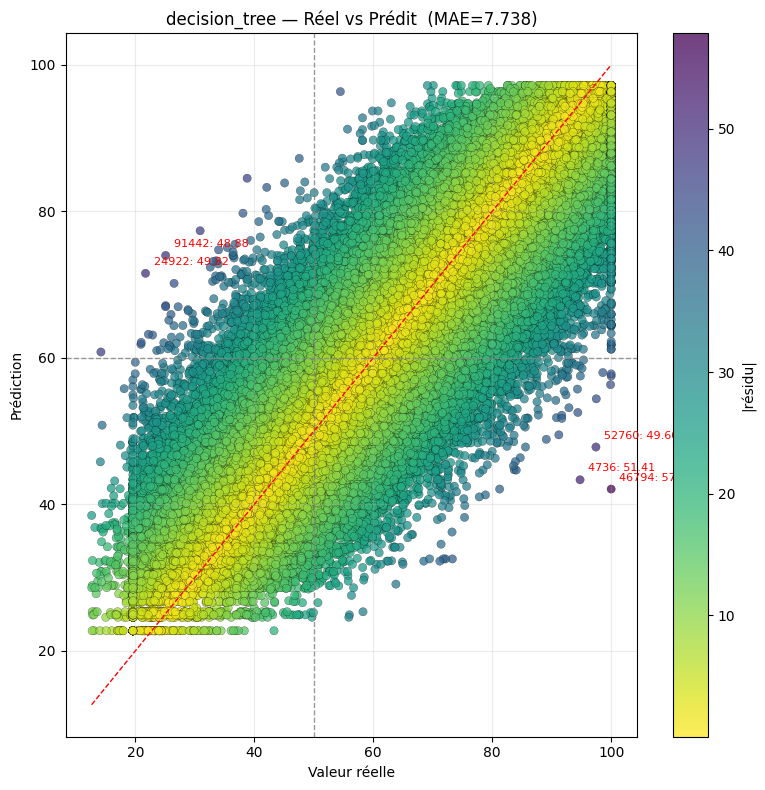

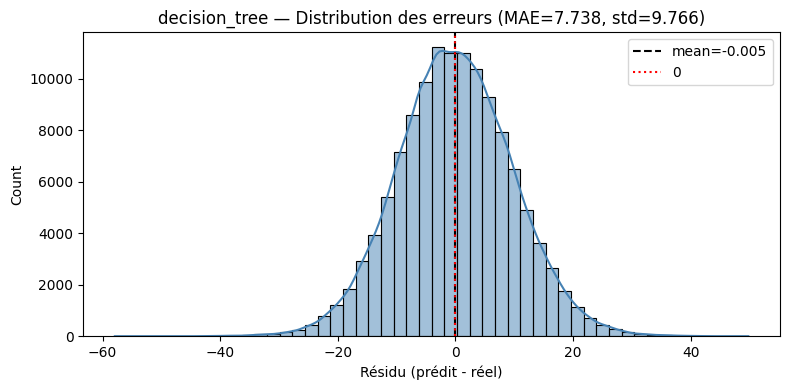

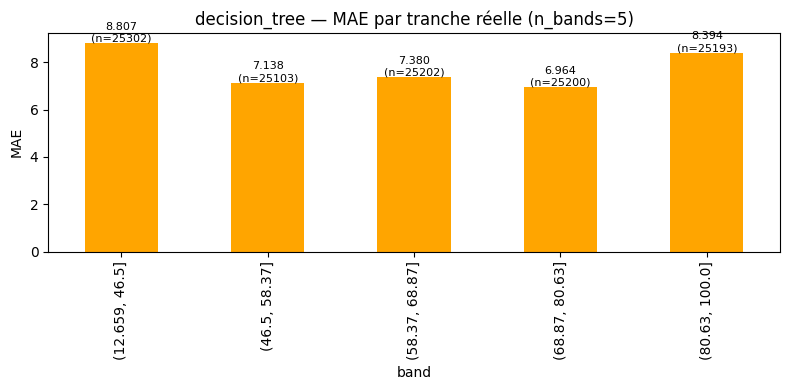

In [33]:
results_pipeline = []
run_id_modeling = current_run_id


regressor_pipeline = Pipeline([
    ("preprocessing", preprocessing_pipeline),
    ("model", DecisionTreeRegressor(max_leaf_nodes=best_tree_size, random_state=1)),
])

regressor_pipeline.fit(X_train_pipe, y_train_pipe)
preds_dt_val = regressor_pipeline.predict(X_val_pipe)
preds_dt_test = regressor_pipeline.predict(X_test_pipe)

mae_dt_val, mae_dt_bands_val = report_split_metrics("Decision Tree", "validation", y_val_pipe, preds_dt_val)
mae_dt_test, mae_dt_bands_test = report_split_metrics("Decision Tree", "test", y_test_pipe, preds_dt_test)
dt_plot_filename = f"{run_id_modeling}_decision_tree_pipeline_mae_overlay.png"
plot_mae_overlay(y_test_pipe, preds_dt_test, "Decision Tree (pipeline)", dt_plot_filename)
plot_preds_vs_true(y_test_pipe, preds_dt_test, name="decision_tree")
plot_error_distribution(y_test_pipe, preds_dt_test, name="decision_tree")
plot_error_by_true_band(y_test_pipe, preds_dt_test, name="decision_tree")
log_experiment(
    model_name="Decision Tree",
    params={"max_leaf_nodes": best_tree_size, "random_state": 1},
    mae_val=mae_dt_val,
    mae_test=mae_dt_test,
    mae_bands_val=mae_dt_bands_val,
    mae_bands_test=mae_dt_bands_test,
    artifacts={"plot": dt_plot_filename},
    run_id=run_id_modeling,
)
results_pipeline.append({"modele": "Decision Tree", "mae_val": mae_dt_val, "mae_test": mae_dt_test, "run_id": run_id_modeling})

MAE validation du modèle Random Forest : 7.5148
  tranche      n        mae
0    0-25   2148  12.043549
1   25-90  89525   7.204567
2  90-100   9127   9.492429
MAE test du modèle Random Forest : 7.4897
  tranche       n        mae
0    0-25    2610  11.971696
1   25-90  111870   7.198251
2  90-100   11520   9.304094


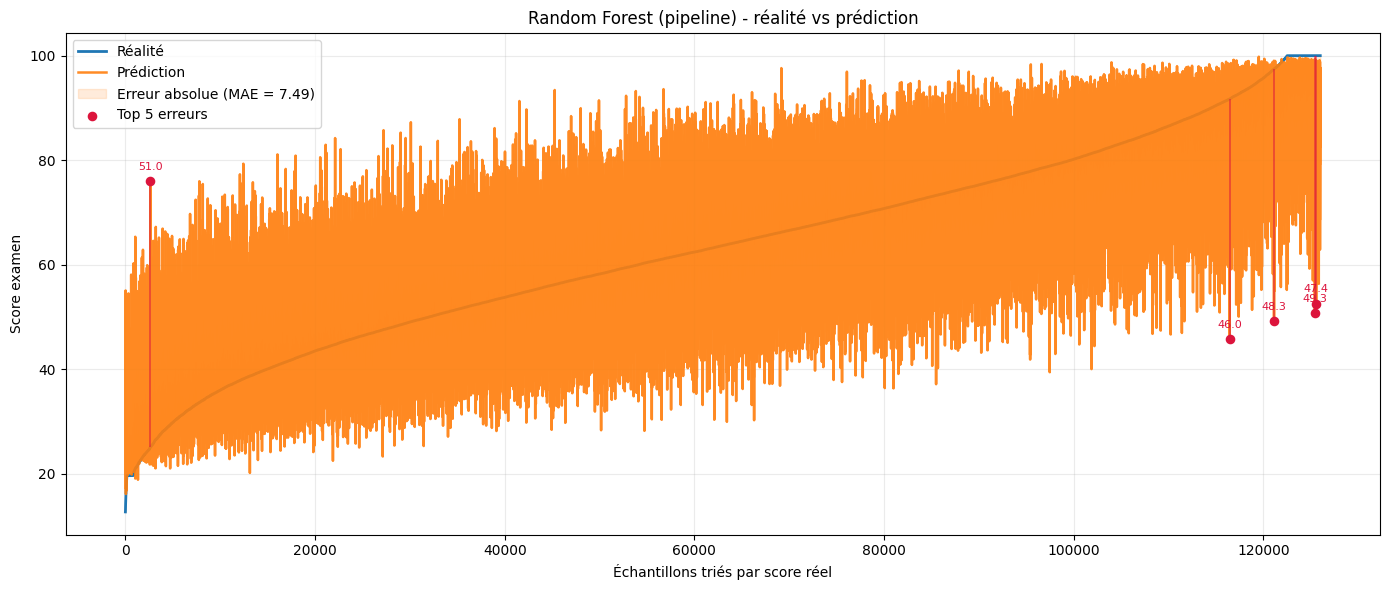

,sample_id,reel,pred,erreur_abs
2645,91442,25.10,76.08,50.98
125432,30941,100.00,50.67,49.33
121123,52760,97.44,49.14,48.30
125567,106324,100.00,52.55,47.45
116432,21535,91.70,45.72,45.98


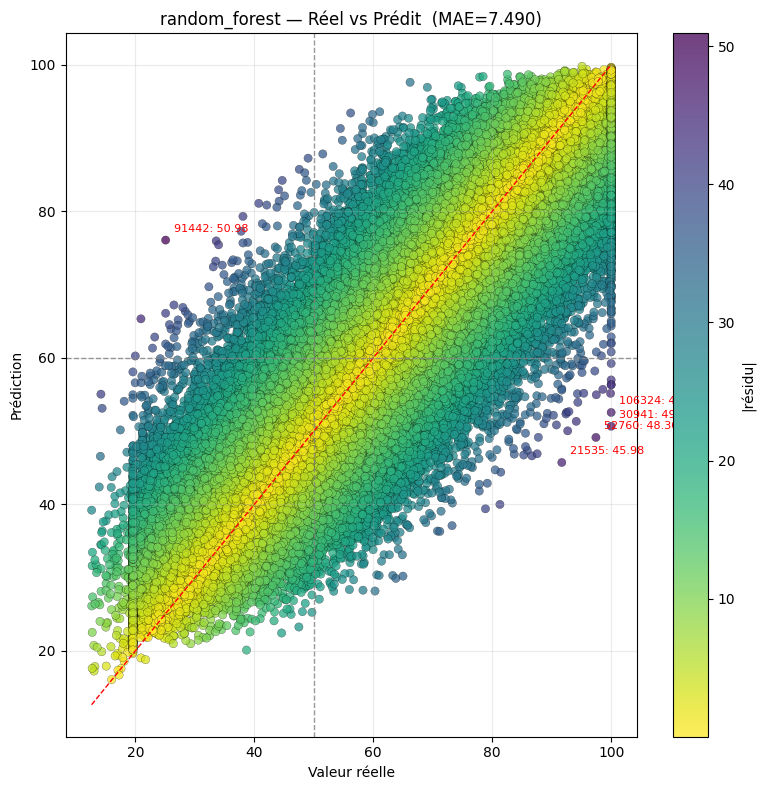

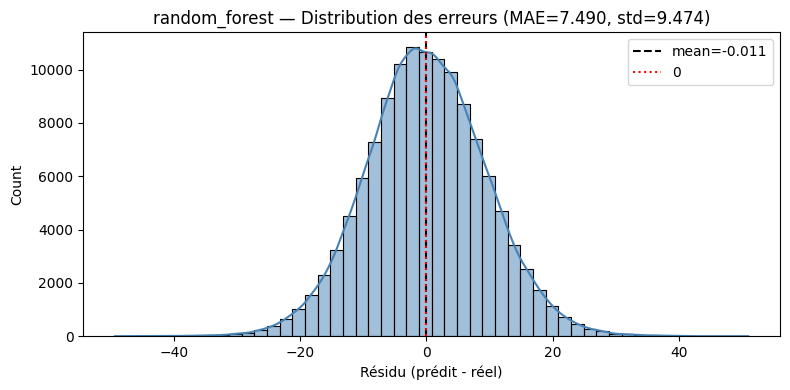

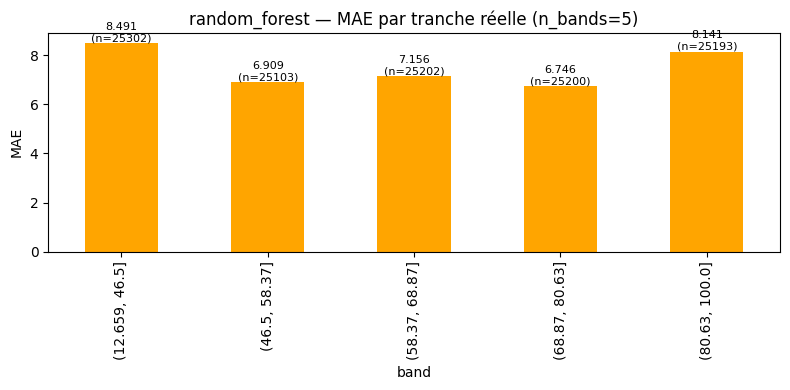

In [34]:




# Random Forest avec pipeline complet

rf_pipeline = Pipeline([
    ("preprocessing", preprocessing_pipeline),
    ("model", RandomForestRegressor(random_state=1, n_estimators=500, n_jobs=6)),
])

rf_pipeline.fit(X_train_pipe, y_train_pipe)
preds_rf_val = rf_pipeline.predict(X_val_pipe)
preds_rf_test = rf_pipeline.predict(X_test_pipe)

mae_rf_val, mae_rf_bands_val = report_split_metrics("Random Forest", "validation", y_val_pipe, preds_rf_val)
mae_rf_test, mae_rf_bands_test = report_split_metrics("Random Forest", "test", y_test_pipe, preds_rf_test)

rf_plot_filename = f"{run_id_modeling}_random_forest_pipeline_mae_overlay.png"
plot_mae_overlay(y_test_pipe, preds_rf_test, "Random Forest (pipeline)", rf_plot_filename)
plot_preds_vs_true(y_test_pipe, preds_rf_test, name="random_forest")
plot_error_distribution(y_test_pipe, preds_rf_test, name="random_forest")
plot_error_by_true_band(y_test_pipe, preds_rf_test, name="random_forest")
log_experiment(
    model_name="Random Forest",
    params={"n_estimators": 500, "random_state": 1},
    mae_val=mae_rf_val,
    mae_test=mae_rf_test,
    mae_bands_val=mae_rf_bands_val,
    mae_bands_test=mae_rf_bands_test,
    artifacts={"plot": rf_plot_filename, "naive_mae_test": float(naive_mae_test)},
    run_id=run_id_modeling,
)
results_pipeline.append({"modele": "Random Forest", "mae_val": mae_rf_val, "mae_test": mae_rf_test, "run_id": run_id_modeling})








MAE validation du modèle XGBoost : 7.2538
  tranche      n        mae
0    0-25   2148  11.577078
1   25-90  89525   6.966453
2  90-100   9127   9.055091
MAE test du modèle XGBoost : 7.2326
  tranche       n        mae
0    0-25    2610  11.500721
1   25-90  111870   6.960524
2  90-100   11520   8.908179


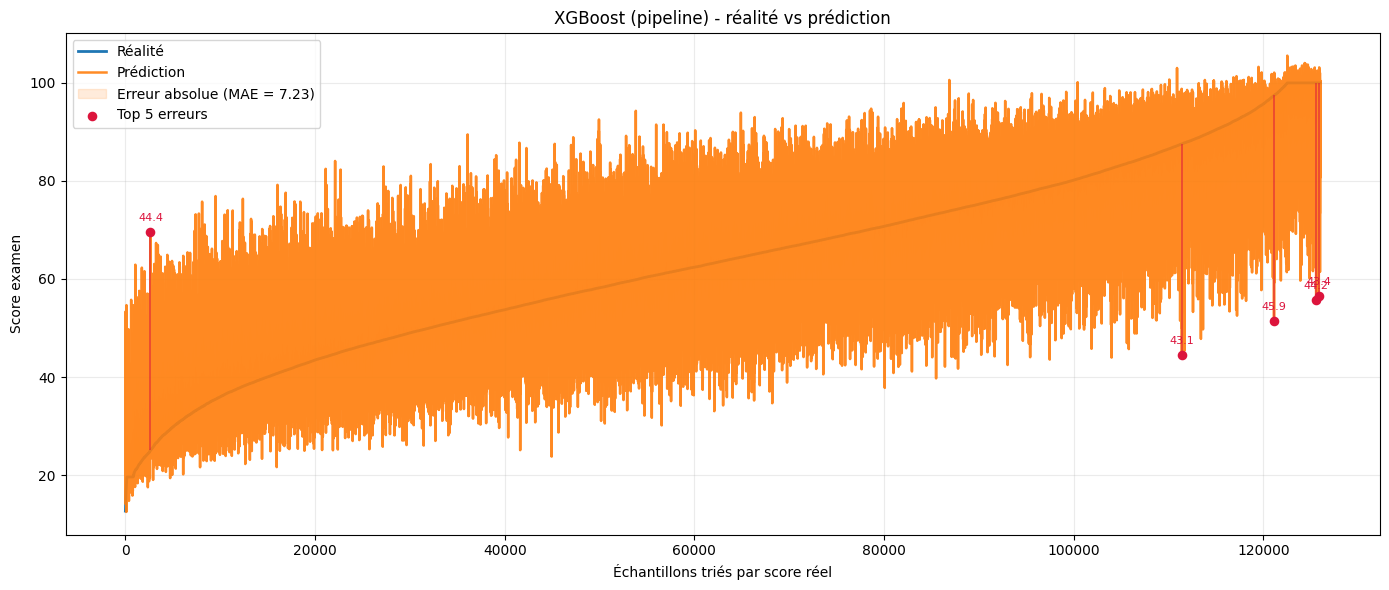

,sample_id,reel,pred,erreur_abs
121123,52760,97.44,51.500000,45.94
2645,91442,25.10,69.540001,44.44
125567,106324,100.00,55.779999,44.22
125844,46794,100.00,56.599998,43.40
111406,92972,87.56,44.459999,43.10


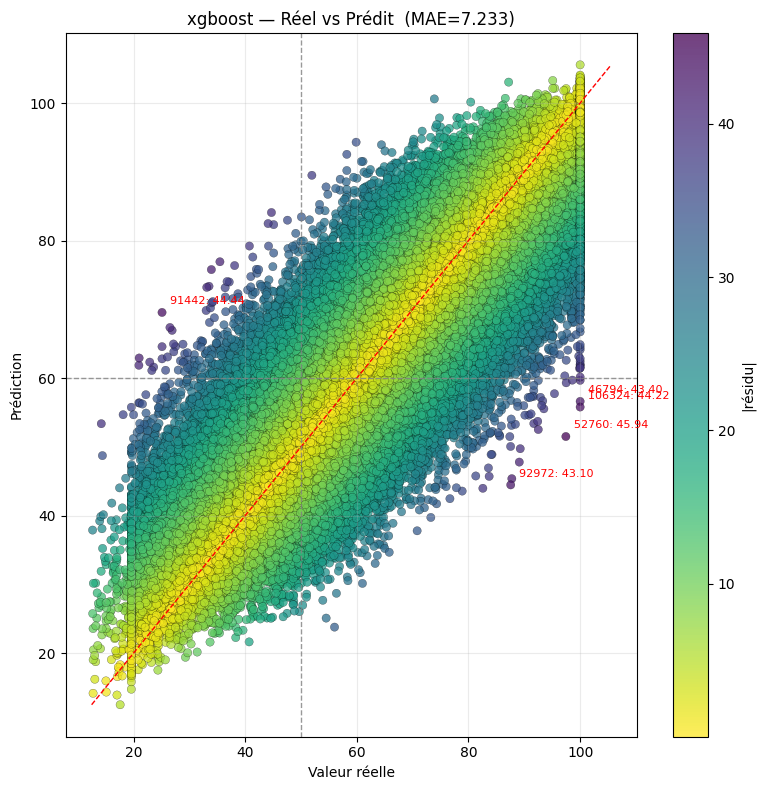

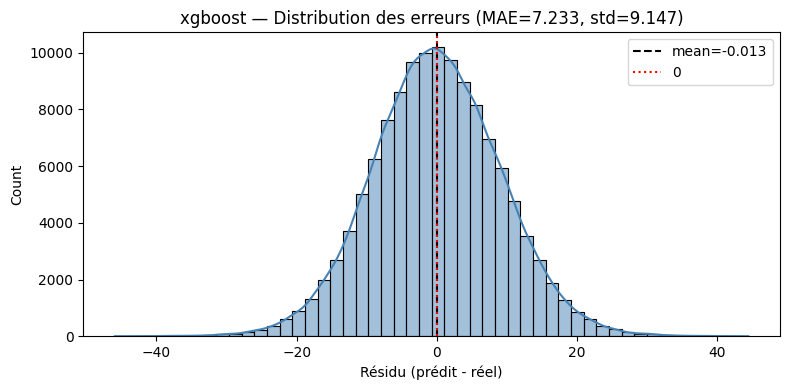

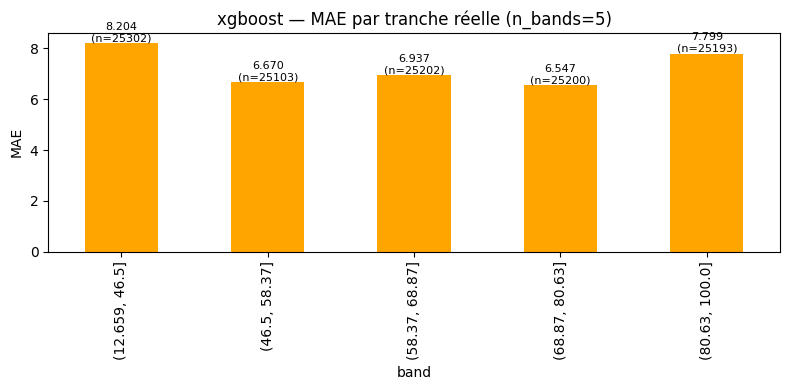

In [35]:
# XGBoost avec le meme preprocessing, mais validation séparée pour early stopping

Model_2_pipeline = XGBRegressor(
    random_state=1,
    n_estimators=3000,
    learning_rate=0.05,
    n_jobs=6,
    early_stopping_rounds=5,
    eval_metric="mae",
)

Model_2_pipeline.fit(
    train_processed_df,
    y_train_pipe,
    eval_set=[(val_processed_df, y_val_pipe)],
    verbose=False,
)

preds_xgb_val = Model_2_pipeline.predict(val_processed_df)
preds_xgb_test = Model_2_pipeline.predict(test_processed_df)

mae_xgb_val, mae_xgb_bands_val = report_split_metrics("XGBoost", "validation", y_val_pipe, preds_xgb_val)
mae_xgb_test, mae_xgb_bands_test = report_split_metrics("XGBoost", "test", y_test_pipe, preds_xgb_test)
xgb_plot_filename = f"{run_id_modeling}_xgboost_pipeline_mae_overlay.png"
plot_mae_overlay(y_test_pipe, preds_xgb_test, "XGBoost (pipeline)", xgb_plot_filename)
plot_preds_vs_true(y_test_pipe, preds_xgb_test, name="xgboost")
plot_error_distribution(y_test_pipe, preds_xgb_test, name="xgboost")
plot_error_by_true_band(y_test_pipe, preds_xgb_test, name="xgboost")
log_experiment(
    model_name="XGBoost",
    params={"random_state": 1, "n_estimators": 3000, "learning_rate": 0.05, "early_stopping_rounds": 5, "eval_metric": "mae"},
    mae_val=mae_xgb_val,
    mae_test=mae_xgb_test,
    mae_bands_val=mae_xgb_bands_val,
    mae_bands_test=mae_xgb_bands_test,
    artifacts={"plot": xgb_plot_filename},
    run_id=run_id_modeling,
)
results_pipeline.append({"modele": "XGBoost", "mae_val": mae_xgb_val, "mae_test": mae_xgb_test, "run_id": run_id_modeling})

Minimum Validation Loss: 7.3388


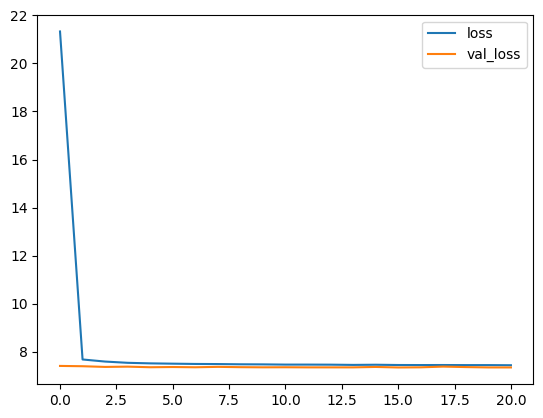

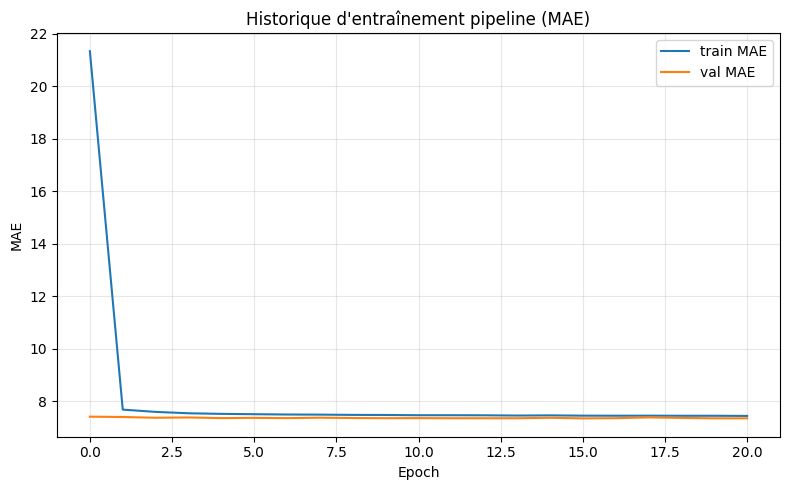

MAE validation du modèle Deep Learning : 7.3388
  tranche      n        mae
0    0-25   2148  11.629887
1   25-90  89525   7.101457
2  90-100   9127   8.657259
MAE test du modèle Deep Learning : 7.3186
  tranche       n        mae
0    0-25    2610  11.636969
1   25-90  111870   7.096085
2  90-100   11520   8.501001


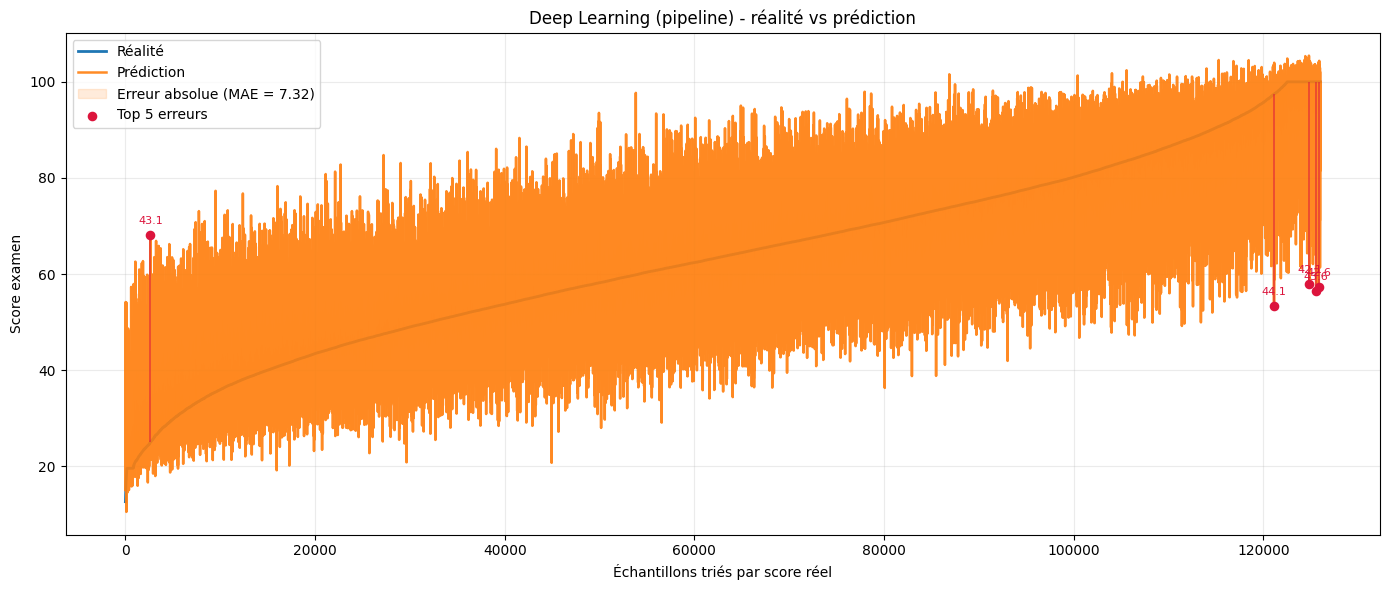

,sample_id,reel,pred,erreur_abs
121123,52760,97.44,53.389999,44.05
125567,106324,100.00,56.400002,43.60
2645,91442,25.10,68.180000,43.08
125844,46794,100.00,57.360001,42.64
124863,100433,100.00,57.860001,42.14


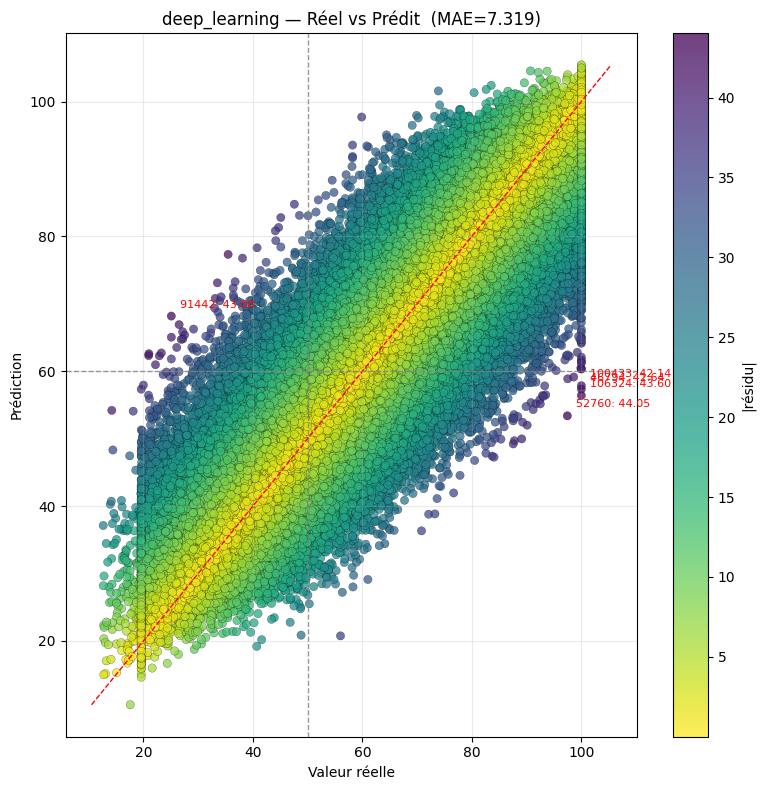

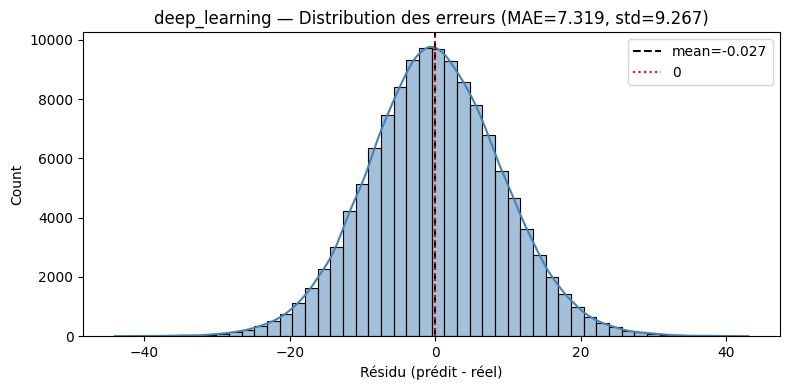

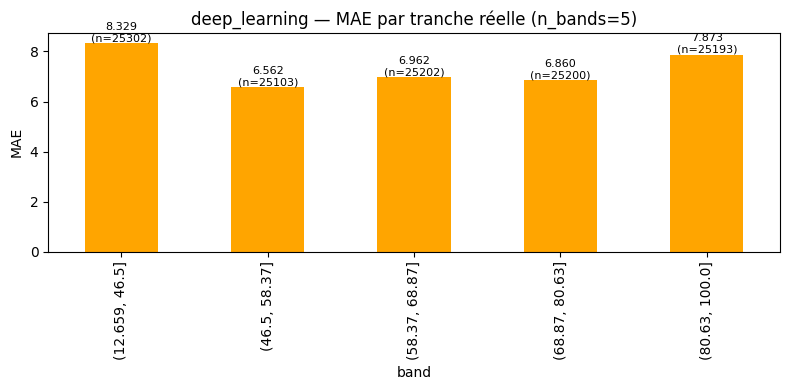

,modele,mae_val,mae_test,run_id
2,XGBoost,7.253820,7.232642,20260506_113332
3,Deep Learning,7.338826,7.318595,20260506_113332
1,Random Forest,7.514839,7.489664,20260506_113332
0,Decision Tree,7.777257,7.737887,20260506_113332


In [36]:
scaler_dl_pipeline = StandardScaler()
train_dl = scaler_dl_pipeline.fit_transform(train_processed_df)
val_dl = scaler_dl_pipeline.transform(val_processed_df)
test_dl = scaler_dl_pipeline.transform(test_processed_df)

input_dim_pipeline = train_dl.shape[1]
model3_pipeline = keras.Sequential([
    keras.layers.Input(shape=(input_dim_pipeline,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.1),
    layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.1),
    layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.1),
    layers.BatchNormalization(),
    keras.layers.Dense(1),
])

model3_pipeline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error',
)

early_stopping_pipeline = keras.callbacks.EarlyStopping(
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
)

history_pipeline = model3_pipeline.fit(
    train_dl,
    y_train_pipe,
    validation_data=(val_dl, y_val_pipe),
    batch_size=256,
    epochs=100,
    callbacks=[early_stopping_pipeline],
    verbose=0,
)

history_pipeline_df = pd.DataFrame(history_pipeline.history)
history_pipeline_df.loc[:, ['loss', 'val_loss']].plot()
print("Minimum Validation Loss: {:0.4f}".format(history_pipeline_df['val_loss'].min()))
plt.figure(figsize=(8, 5))
plt.plot(history_pipeline.history['loss'], label='train MAE')
plt.plot(history_pipeline.history['val_loss'], label='val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title("Historique d'entraînement pipeline (MAE)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
dl_history_filename = f"../Graph/{run_id_modeling}_dl_pipeline_training_history.png"
plt.savefig(dl_history_filename)
plt.show()

preds_dl_val = model3_pipeline.predict(val_dl, verbose=0).ravel()
preds_dl_test = model3_pipeline.predict(test_dl, verbose=0).ravel()

mae_dl_val, mae_dl_bands_val = report_split_metrics("Deep Learning", "validation", y_val_pipe, preds_dl_val)
mae_dl_test, mae_dl_bands_test = report_split_metrics("Deep Learning", "test", y_test_pipe, preds_dl_test)
dl_plot_filename = f"{run_id_modeling}_dl_pipeline_mae_overlay.png"
plot_mae_overlay(y_test_pipe, preds_dl_test, "Deep Learning (pipeline)", dl_plot_filename)
plot_preds_vs_true(y_test_pipe, preds_dl_test, name="deep_learning")
plot_error_distribution(y_test_pipe, preds_dl_test, name="deep_learning")
plot_error_by_true_band(y_test_pipe, preds_dl_test, name="deep_learning")
dl_params = {
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "batch_size": 256,
    "epochs": 100,
    "early_stopping_patience": 5,
}
log_experiment(
    model_name="Deep Learning",
    params=dl_params,
    mae_val=mae_dl_val,
    mae_test=mae_dl_test,
    mae_bands_val=mae_dl_bands_val,
    mae_bands_test=mae_dl_bands_test,
    artifacts={"plot": dl_plot_filename, "history_plot": dl_history_filename},
    run_id=run_id_modeling,
)
results_pipeline.append({"modele": "Deep Learning", "mae_val": mae_dl_val, "mae_test": mae_dl_test, "run_id": run_id_modeling})

results_pipeline_df = pd.DataFrame(results_pipeline)
display(results_pipeline_df.sort_values("mae_test"))

In [37]:
print("Classification report pour Naïf :")
classification_report(y_test_pipe, np.repeat(y_train_pipe.mean(), len(y_test_pipe)))

Classification report pour Naïf :
Total : 126000
Vrais positifs (réussite prédite et réelle) : 93980 (74.59%)
Vrais négatifs (échec prédit et réel) : 0 (0.00%)
Faux positifs (réussite prédite mais échec réel) : 32020 (25.41%)
Faux négatifs (échec prédit mais réussite réelle) : 0 (0.00%)
Précision (réussite prédite parmi les réussites réelles) : 74.59%
Rappel : N/A
precision global (prédictions correctes parmi toutes les prédictions) : 74.59%


In [38]:
print("Classification report pour Decision Tree :")
classification_report(y_test_pipe, preds_dt_test)

Classification report pour Decision Tree :
Total : 126000
Vrais positifs (réussite prédite et réelle) : 86663 (68.78%)
Vrais négatifs (échec prédit et réel) : 22479 (17.84%)
Faux positifs (réussite prédite mais échec réel) : 9541 (7.57%)
Faux négatifs (échec prédit mais réussite réelle) : 7317 (5.81%)
Précision (réussite prédite parmi les réussites réelles) : 90.08%
Rappel (echec prédite parmi les echecs réelles) : 75.44%
precision global (prédictions correctes parmi toutes les prédictions) : 86.62%


In [39]:
print("Classification report pour Random Forest :")
classification_report(y_test_pipe, preds_rf_test)

Classification report pour Random Forest :
Total : 126000
Vrais positifs (réussite prédite et réelle) : 86988 (69.04%)
Vrais négatifs (échec prédit et réel) : 22916 (18.19%)
Faux positifs (réussite prédite mais échec réel) : 9104 (7.23%)
Faux négatifs (échec prédit mais réussite réelle) : 6992 (5.55%)
Précision (réussite prédite parmi les réussites réelles) : 90.53%
Rappel (echec prédite parmi les echecs réelles) : 76.62%
precision global (prédictions correctes parmi toutes les prédictions) : 87.23%


In [40]:
print("Classification report pour XGBoost :")
classification_report(y_test_pipe, preds_xgb_test)

Classification report pour XGBoost :
Total : 126000
Vrais positifs (réussite prédite et réelle) : 87235 (69.23%)
Vrais négatifs (échec prédit et réel) : 23231 (18.44%)
Faux positifs (réussite prédite mais échec réel) : 8789 (6.98%)
Faux négatifs (échec prédit mais réussite réelle) : 6745 (5.35%)
Précision (réussite prédite parmi les réussites réelles) : 90.85%
Rappel (echec prédite parmi les echecs réelles) : 77.50%
precision global (prédictions correctes parmi toutes les prédictions) : 87.67%


In [41]:
# calcul des pourcentages : du nombre de personnes ayant reussi et predit comme reussite, du nombre de personnes ayant reussi et predit comme echec, du nombre de personnes ayant echoué et predit comme reussite, du nombre de personnes ayant echoué et predit comme echec




print("Classification report pour Deep Learning :")
classification_report(y_test_pipe, preds_dl_test)


Classification report pour Deep Learning :
Total : 126000
Vrais positifs (réussite prédite et réelle) : 87188 (69.20%)
Vrais négatifs (échec prédit et réel) : 23128 (18.36%)
Faux positifs (réussite prédite mais échec réel) : 8892 (7.06%)
Faux négatifs (échec prédit mais réussite réelle) : 6792 (5.39%)
Précision (réussite prédite parmi les réussites réelles) : 90.75%
Rappel (echec prédite parmi les echecs réelles) : 77.30%
precision global (prédictions correctes parmi toutes les prédictions) : 87.55%


Distribution des tranches de score - Naïf :


type_prediction,TP,TN,FP,FN,total,erreurs,pct_tp_tranche,pct_tn_tranche,pct_fp_tranche,pct_fn_tranche,pct_erreur_tranche
tranche_score_reel,,,,,,,,,,,
0-25,0,0,2610,0,2610,2610,0.0,0.0,100.0,0.0,100.0
25-40,0,0,12316,0,12316,12316,0.0,0.0,100.0,0.0,100.0
40-45,0,0,7578,0,7578,7578,0.0,0.0,100.0,0.0,100.0
45-50,0,0,9516,0,9516,9516,0.0,0.0,100.0,0.0,100.0
50-55,0,0,10639,0,10639,10639,0.0,0.0,100.0,0.0,100.0
55-60,0,0,11440,0,11440,11440,0.0,0.0,100.0,0.0,100.0
60-75,35298,0,0,0,35298,0,100.0,0.0,0.0,0.0,0.0
75-100,36603,0,0,0,36603,0,100.0,0.0,0.0,0.0,0.0


Tranche avec le plus d'erreurs de classification : 25-40 | taux d'erreur = 100.00% | FP = 12316 | FN = 0


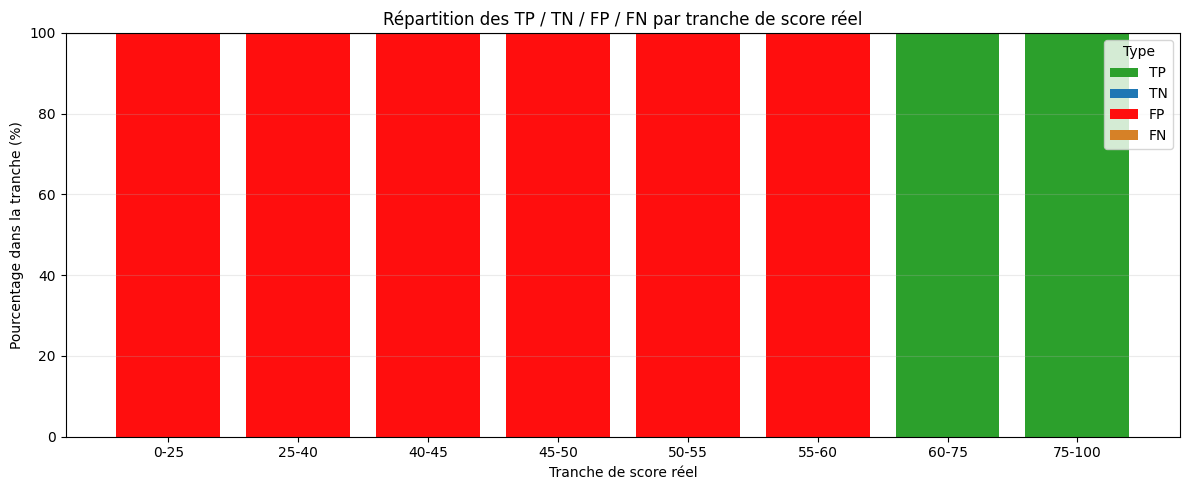

type_prediction,TP,TN,FP,FN,total,erreurs,pct_erreur_tranche,pct_tp_tranche,pct_tn_tranche,pct_fp_tranche,pct_fn_tranche
tranche_score_reel,,,,,,,,,,,
0-25,0,0,2610,0,2610,2610,100.0,0.0,0.0,100.0,0.0
25-40,0,0,12316,0,12316,12316,100.0,0.0,0.0,100.0,0.0
40-45,0,0,7578,0,7578,7578,100.0,0.0,0.0,100.0,0.0
45-50,0,0,9516,0,9516,9516,100.0,0.0,0.0,100.0,0.0
50-55,0,0,10639,0,10639,10639,100.0,0.0,0.0,100.0,0.0
55-60,0,0,11440,0,11440,11440,100.0,0.0,0.0,100.0,0.0
60-75,35298,0,0,0,35298,0,0.0,100.0,0.0,0.0,0.0
75-100,36603,0,0,0,36603,0,0.0,100.0,0.0,0.0,0.0


In [42]:
print("Distribution des tranches de score - Naïf :")
score_band_distribution(y_test_pipe, np.repeat(y_train_pipe.mean(), len(y_test_pipe)))

Distribution des tranches de score - Decision Tree :


type_prediction,TP,TN,FP,FN,total,erreurs,pct_tp_tranche,pct_tn_tranche,pct_fp_tranche,pct_fn_tranche,pct_erreur_tranche
tranche_score_reel,,,,,,,,,,,
0-25,0,2601,9,0,2610,9,0.00,99.66,0.34,0.00,0.34
25-40,0,11997,319,0,12316,319,0.00,97.41,2.59,0.00,2.59
40-45,0,7047,531,0,7578,531,0.00,92.99,7.01,0.00,7.01
45-50,0,8351,1165,0,9516,1165,0.00,87.76,12.24,0.00,12.24
50-55,0,7988,2651,0,10639,2651,0.00,75.08,24.92,0.00,24.92
55-60,0,6618,4822,0,11440,4822,0.00,57.85,42.15,0.00,42.15
60-75,26968,0,0,8330,35298,8330,76.40,0.00,0.00,23.60,23.60
75-100,35826,0,0,777,36603,777,97.88,0.00,0.00,2.12,2.12


Tranche avec le plus d'erreurs de classification : 55-60 | taux d'erreur = 42.15% | FP = 4822 | FN = 0


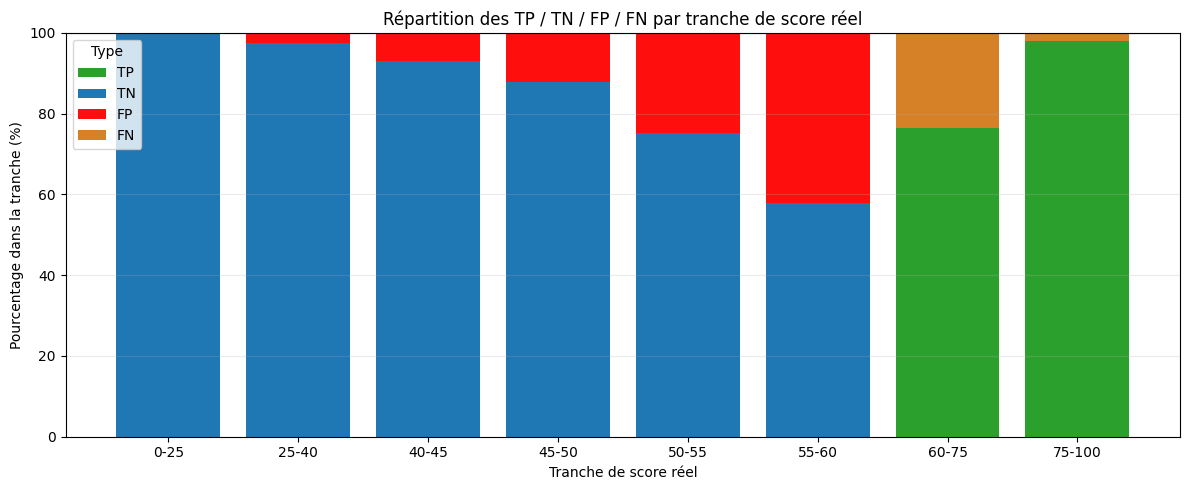

type_prediction,TP,TN,FP,FN,total,erreurs,pct_erreur_tranche,pct_tp_tranche,pct_tn_tranche,pct_fp_tranche,pct_fn_tranche
tranche_score_reel,,,,,,,,,,,
0-25,0,2601,9,0,2610,9,0.344828,0.000000,99.655172,0.344828,0.000000
25-40,0,11997,319,0,12316,319,2.590127,0.000000,97.409873,2.590127,0.000000
40-45,0,7047,531,0,7578,531,7.007126,0.000000,92.992874,7.007126,0.000000
45-50,0,8351,1165,0,9516,1165,12.242539,0.000000,87.757461,12.242539,0.000000
50-55,0,7988,2651,0,10639,2651,24.917755,0.000000,75.082245,24.917755,0.000000
55-60,0,6618,4822,0,11440,4822,42.150350,0.000000,57.849650,42.150350,0.000000
60-75,26968,0,0,8330,35298,8330,23.599071,76.400929,0.000000,0.000000,23.599071
75-100,35826,0,0,777,36603,777,2.122777,97.877223,0.000000,0.000000,2.122777


In [43]:
print("Distribution des tranches de score - Decision Tree :")
score_band_distribution(y_test_pipe, preds_dt_test)

Distribution des tranches de score - Random Forest :


type_prediction,TP,TN,FP,FN,total,erreurs,pct_tp_tranche,pct_tn_tranche,pct_fp_tranche,pct_fn_tranche,pct_erreur_tranche
tranche_score_reel,,,,,,,,,,,
0-25,0,2606,4,0,2610,4,0.00,99.85,0.15,0.00,0.15
25-40,0,12031,285,0,12316,285,0.00,97.69,2.31,0.00,2.31
40-45,0,7085,493,0,7578,493,0.00,93.49,6.51,0.00,6.51
45-50,0,8424,1092,0,9516,1092,0.00,88.52,11.48,0.00,11.48
50-55,0,8109,2530,0,10639,2530,0.00,76.22,23.78,0.00,23.78
55-60,0,6651,4789,0,11440,4789,0.00,58.14,41.86,0.00,41.86
60-75,27257,0,0,8041,35298,8041,77.22,0.00,0.00,22.78,22.78
75-100,35906,0,0,697,36603,697,98.10,0.00,0.00,1.90,1.90


Tranche avec le plus d'erreurs de classification : 55-60 | taux d'erreur = 41.86% | FP = 4789 | FN = 0


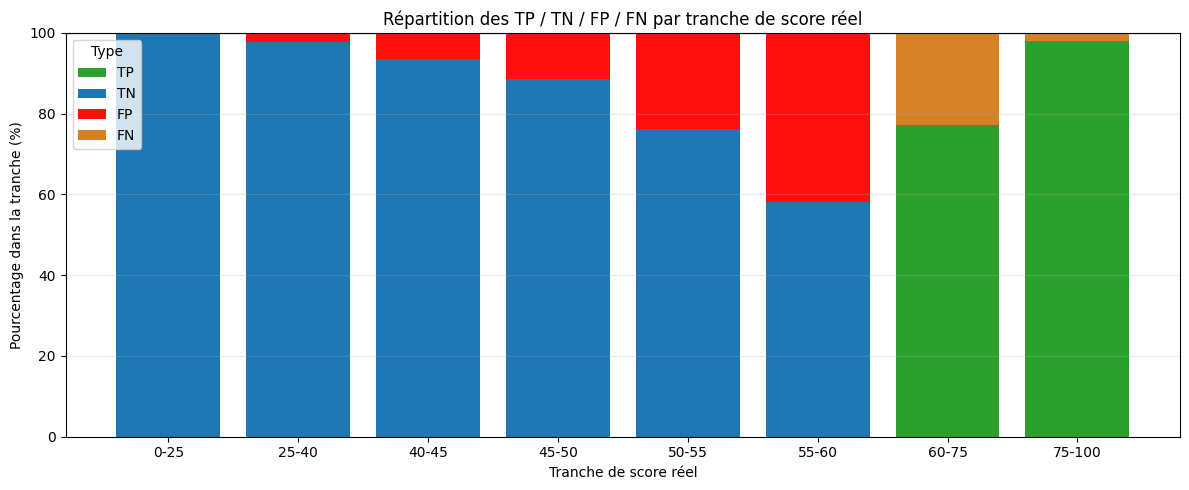

type_prediction,TP,TN,FP,FN,total,erreurs,pct_erreur_tranche,pct_tp_tranche,pct_tn_tranche,pct_fp_tranche,pct_fn_tranche
tranche_score_reel,,,,,,,,,,,
0-25,0,2606,4,0,2610,4,0.153257,0.000000,99.846743,0.153257,0.000000
25-40,0,12031,285,0,12316,285,2.314063,0.000000,97.685937,2.314063,0.000000
40-45,0,7085,493,0,7578,493,6.505674,0.000000,93.494326,6.505674,0.000000
45-50,0,8424,1092,0,9516,1092,11.475410,0.000000,88.524590,11.475410,0.000000
50-55,0,8109,2530,0,10639,2530,23.780430,0.000000,76.219570,23.780430,0.000000
55-60,0,6651,4789,0,11440,4789,41.861888,0.000000,58.138112,41.861888,0.000000
60-75,27257,0,0,8041,35298,8041,22.780327,77.219673,0.000000,0.000000,22.780327
75-100,35906,0,0,697,36603,697,1.904216,98.095784,0.000000,0.000000,1.904216


In [44]:
print("Distribution des tranches de score - Random Forest :")
score_band_distribution(y_test_pipe, preds_rf_test)

Distribution des tranches de score - XGBoost :


type_prediction,TP,TN,FP,FN,total,erreurs,pct_tp_tranche,pct_tn_tranche,pct_fp_tranche,pct_fn_tranche,pct_erreur_tranche
tranche_score_reel,,,,,,,,,,,
0-25,0,2605,5,0,2610,5,0.00,99.81,0.19,0.00,0.19
25-40,0,12088,228,0,12316,228,0.00,98.15,1.85,0.00,1.85
40-45,0,7146,432,0,7578,432,0.00,94.30,5.70,0.00,5.70
45-50,0,8540,976,0,9516,976,0.00,89.74,10.26,0.00,10.26
50-55,0,8182,2457,0,10639,2457,0.00,76.91,23.09,0.00,23.09
55-60,0,6643,4797,0,11440,4797,0.00,58.07,41.93,0.00,41.93
60-75,27481,0,0,7817,35298,7817,77.85,0.00,0.00,22.15,22.15
75-100,36001,0,0,602,36603,602,98.36,0.00,0.00,1.64,1.64


Tranche avec le plus d'erreurs de classification : 55-60 | taux d'erreur = 41.93% | FP = 4797 | FN = 0


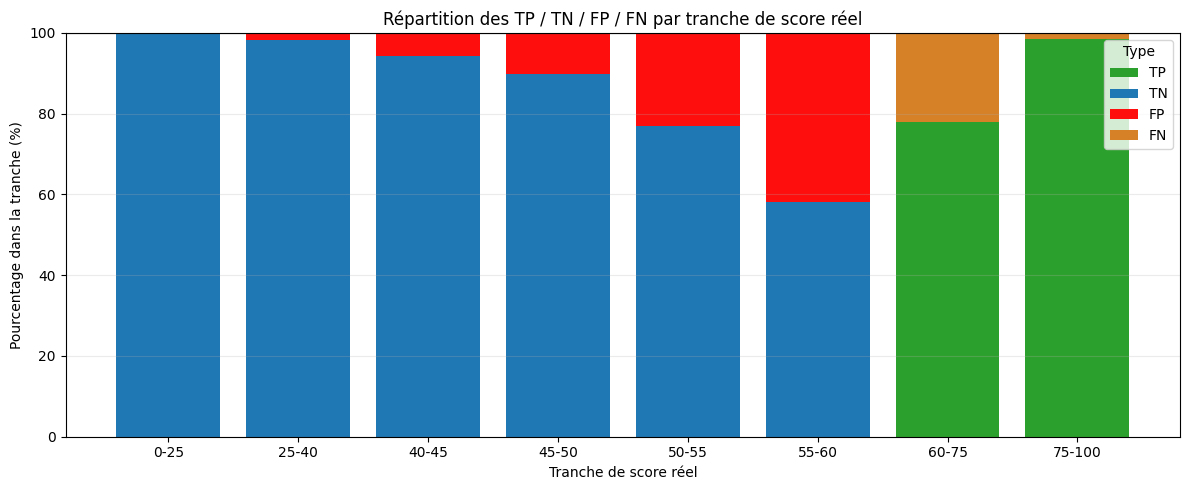

type_prediction,TP,TN,FP,FN,total,erreurs,pct_erreur_tranche,pct_tp_tranche,pct_tn_tranche,pct_fp_tranche,pct_fn_tranche
tranche_score_reel,,,,,,,,,,,
0-25,0,2605,5,0,2610,5,0.191571,0.000000,99.808429,0.191571,0.000000
25-40,0,12088,228,0,12316,228,1.851250,0.000000,98.148750,1.851250,0.000000
40-45,0,7146,432,0,7578,432,5.700713,0.000000,94.299287,5.700713,0.000000
45-50,0,8540,976,0,9516,976,10.256410,0.000000,89.743590,10.256410,0.000000
50-55,0,8182,2457,0,10639,2457,23.094276,0.000000,76.905724,23.094276,0.000000
55-60,0,6643,4797,0,11440,4797,41.931818,0.000000,58.068182,41.931818,0.000000
60-75,27481,0,0,7817,35298,7817,22.145731,77.854269,0.000000,0.000000,22.145731
75-100,36001,0,0,602,36603,602,1.644674,98.355326,0.000000,0.000000,1.644674


In [45]:
print("Distribution des tranches de score - XGBoost :")
score_band_distribution(y_test_pipe, preds_xgb_test)

Distribution des tranches de score - Deep Learning :


type_prediction,TP,TN,FP,FN,total,erreurs,pct_tp_tranche,pct_tn_tranche,pct_fp_tranche,pct_fn_tranche,pct_erreur_tranche
tranche_score_reel,,,,,,,,,,,
0-25,0,2605,5,0,2610,5,0.00,99.81,0.19,0.00,0.19
25-40,0,12094,222,0,12316,222,0.00,98.20,1.80,0.00,1.80
40-45,0,7162,416,0,7578,416,0.00,94.51,5.49,0.00,5.49
45-50,0,8583,933,0,9516,933,0.00,90.20,9.80,0.00,9.80
50-55,0,8325,2314,0,10639,2314,0.00,78.25,21.75,0.00,21.75
55-60,0,6892,4548,0,11440,4548,0.00,60.24,39.76,0.00,39.76
60-75,26937,0,0,8361,35298,8361,76.31,0.00,0.00,23.69,23.69
75-100,35910,0,0,693,36603,693,98.11,0.00,0.00,1.89,1.89


Tranche avec le plus d'erreurs de classification : 55-60 | taux d'erreur = 39.76% | FP = 4548 | FN = 0


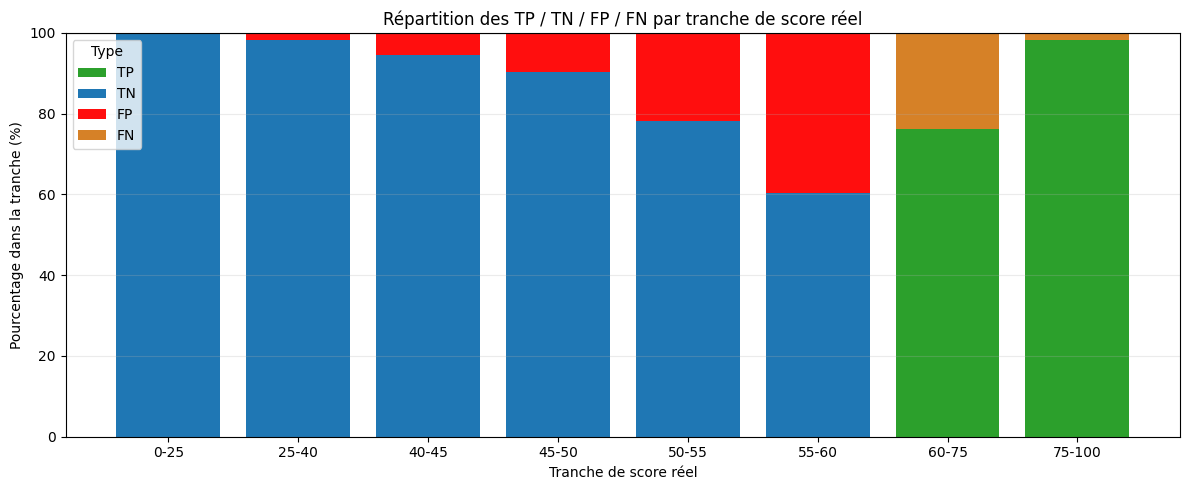

type_prediction,TP,TN,FP,FN,total,erreurs,pct_erreur_tranche,pct_tp_tranche,pct_tn_tranche,pct_fp_tranche,pct_fn_tranche
tranche_score_reel,,,,,,,,,,,
0-25,0,2605,5,0,2610,5,0.191571,0.000000,99.808429,0.191571,0.000000
25-40,0,12094,222,0,12316,222,1.802533,0.000000,98.197467,1.802533,0.000000
40-45,0,7162,416,0,7578,416,5.489575,0.000000,94.510425,5.489575,0.000000
45-50,0,8583,933,0,9516,933,9.804540,0.000000,90.195460,9.804540,0.000000
50-55,0,8325,2314,0,10639,2314,21.750164,0.000000,78.249836,21.750164,0.000000
55-60,0,6892,4548,0,11440,4548,39.755245,0.000000,60.244755,39.755245,0.000000
60-75,26937,0,0,8361,35298,8361,23.686894,76.313106,0.000000,0.000000,23.686894
75-100,35910,0,0,693,36603,693,1.893287,98.106713,0.000000,0.000000,1.893287


In [46]:
# calcul pourcentage de prédictions dans chaque tranche de score pour les vrais échecs et les vraies réussites


print("Distribution des tranches de score - Deep Learning :")
score_band_distribution(y_test_pipe, preds_dl_test)
